<img src="logos/Logo_de_la_Facultad_Experimental_de_Ciencia_y_Tecnología.svg.png"
     width="250"
     style="display: block; margin-left: auto; margin-right: auto;">

# Exploratory Data Analysis: Premier League

## Purpose

This notebook presents a teaching example of **exploratory data analysis (EDA)**. Its goal is to understand the dataset's structure, quality, and patterns before building a model to predict the result of a football match.

EDA is not intended to prove causality or make final modeling decisions. It aims to:

- detect data quality issues;
- describe distributions and relationships;
- formulate hypotheses;
- acknowledge uncertainty and limitations;
- propose decisions that must later be validated.

**Unit of observation:** An English Premier League football match  
**Target variable:** `FTR` Full Time Result (`H`=Home Win, `D`=Draw, `A`=Away Win)  
**Downstream problem type:** Multiclass Classification.


## Guiding questions

1. Which variables and data types does the dataset contain?
2. Are there duplicates, missing values, or suspicious values?
3. How is the target variable distributed?
4. How is the result associated with home/away, season, half-time result, and team strength?
5. Are there relevant interactions between variables?
6. What useful information can be extracted from the bookmaker odds?
7. Which preprocessing hypotheses should be validated during modeling?

> The observed associations describe this sample. By themselves, they do not imply causal relationships.


## Configuration

Set up the environment: group the main imports, define the data path and figure output directory (relative, reproducible), fix the random seed, and tune display options.


In [129]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RANDOM_STATE = 42

DATA_FOLDER = "data/processed"
DATASET_NAME = "premier_league_2021_2026.csv"

MAX_ROWS = 50
MAX_COLS = 50

# Allow execution from either the project root or the notebooks/ directory.
PROJECT_ROOT = Path.cwd()
print(PROJECT_ROOT)
if not (PROJECT_ROOT  / DATA_FOLDER / DATASET_NAME ).exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / DATA_FOLDER / DATASET_NAME
FIG_DIR = PROJECT_ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

assert DATA_PATH.exists(), f"Dataset not found at {DATA_PATH}"

pd.set_option("display.max_columns", MAX_COLS)
pd.set_option("display.max_rows", MAX_ROWS)
pd.set_option("display.float_format", "{:.3f}".format)
plt.style.use("seaborn-v0_8-whitegrid")


c:\Users\Usuario\Desktop\UNIVERSIDAD\machine_learning\premier_league_football_predictor\notebooks


## Data loading

Load the processed dataset (already merged from the per-season raw files by `src/merge_seasons.py`) and confirm its dimensions and a few first rows.


In [130]:
premier_df = pd.read_csv(DATA_PATH)

print(f"Dimensions: {premier_df.shape[0]} rows × {premier_df.shape[1]} columns")
premier_df.head()


Dimensions: 1900 rows × 157 columns


,Season,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,Referee,HS,AS,HST,AST,HF,AF,HC,AC,HY,AY,HR,AR,...,BFECAHA,BFDH,BFDD,BFDA,BMGMH,BMGMD,BMGMA,CLH,CLD,CLA,LBH,LBD,LBA,BFDCH,BFDCD,BFDCA,BMGMCH,BMGMCD,BMGMCA,CLCH,CLCD,CLCA,LBCH,LBCD,LBCA
0,2021-2022,E0,13/08/2021,20:00,Brentford,Arsenal,2,0,H,1,0,H,M Oliver,8,22,3,4,12,8,2,5,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2021-2022,E0,14/08/2021,12:30,Man United,Leeds,5,1,H,1,0,H,P Tierney,16,10,8,3,11,9,5,4,1,2,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2021-2022,E0,14/08/2021,15:00,Burnley,Brighton,1,2,A,1,0,H,D Coote,14,14,3,8,10,7,7,6,2,1,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2021-2022,E0,14/08/2021,15:00,Chelsea,Crystal Palace,3,0,H,2,0,H,J Moss,13,4,6,1,15,11,5,2,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2021-2022,E0,14/08/2021,15:00,Everton,Southampton,3,1,H,0,1,A,A Madley,14,6,6,3,13,15,6,8,2,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# 1. Data understanding and quality

- `Season` serves as an identifier for the season the data originates from, although it is stored as a string.
- `Div` indicates the league division and is also stored as a string; it contains only a single unique value (`E0`).
- `Date` and `Time` are strings representing the date and time of the match.
- `HomeTeam` and `AwayTeam` contain string values representing the team names.
- `FTR` and `HTR` represent the full-time and half-time match results, respectively: categorical variables encoded as (`H` = Home, `A` = Away, `D` = Draw). `FTR` is the target variable.
- `FTHG`, `FTAG`, `HTHG`, and `HTAG` denote the goals scored: discrete counts stored as integers.
- `Referee` refers to the referee's name: a high-cardinality categorical feature (40 referees across 1900 matches) whose predictive power is doubtful.
- The match statistics columns (`HS`, `AS`, `HST`, `AST`, `HF`, `AF`, `HC`, `AC`, `HY`, `AY`, `HR`, `AR`) are discrete counts that are only known after the match concludes: they are unsuitable for prediction purposes (high risk of data leakage).
- The betting odds columns (`B365H`, `AvgH`, `MaxA`, `AHh`, ...) are numerical features that encode the implied probability assigned by the market to each outcome. They cover various markets (profit, Over/Under 2.5 goals, Asian Handicap, and their closing line versions) across multiple bookmakers.
- The match identifier is composite: `Season`, `Div`, `Date`, `Time`, `HomeTeam`, and `AwayTeam` jointly form a composite key that uniquely identifies a single row.

In [131]:
# Compact structural summary: dtype + non-null counts per column.
# NOTE: verbose=True/show_counts=True prints all 157 columns, flooding the
# output; a compact info() plus the quality_summary table below covers the
# same information legibly.
premier_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1900 entries, 0 to 1899
Columns: 157 entries, Season to LBCA
dtypes: float64(132), int64(16), str(9)
memory usage: 2.3 MB


In [132]:
quality_summary = pd.DataFrame({
    "dtype": premier_df.dtypes.astype(str),
    "missing_n": premier_df.isna().sum(),
    "missing_pct": premier_df.isna().mean().mul(100),
    "unique_n": premier_df.nunique(dropna=True),
})
quality_summary.sort_values("missing_pct", ascending=False )


,dtype,missing_n,missing_pct,unique_n
CLCH,float64,1640,86.316,73
CLCA,float64,1640,86.316,68
CLCD,float64,1640,86.316,30
LBCH,float64,1619,85.211,74
LBCD,float64,1619,85.211,30
...,...,...,...,...
AvgC<2.5,float64,0,0.000,225
AvgCAHA,float64,0,0.000,52
AHCh,float64,0,0.000,23
AvgCAHH,float64,0,0.000,47


In [133]:
checks = pd.Series({
    "duplicated_rows": premier_df.duplicated().sum(),
    "negative_goals_home": premier_df["FTHG"].lt(0).sum(),
    "negative_goals_away": premier_df["FTAG"].lt(0).sum(),
    "negative_goals_home_half_time": premier_df["HTHG"].lt(0).sum(),
    "negative_goals_away_half_time": premier_df["HTAG"].lt(0).sum(),
    "draw_match": ( premier_df[ "FTR" ] == "D" ).sum(),
    "home_win_match": ( premier_df[ "FTR" ] == "H" ).sum(),
    "away_win_match": ( premier_df[ "FTR" ] == "A" ).sum(),
    "yellow_card_negative_home": premier_df[ "HY" ].lt(0).sum(),
    "yellow_card_negative_away": premier_df[ "AY" ].lt(0).sum(),
    "negative_shots_home": premier_df["HS"].lt(0).sum(),
    "negative_shots_away": premier_df["AS"].lt(0).sum(),
    "negative_shots_at_target_home": premier_df["HST"].lt(0).sum(),
    "negative_shots_at_target_away": premier_df["AST"].lt(0).sum(),
    "negative_fouls_home": premier_df["HF"].lt(0).sum(),
    "negative_fouls_away": premier_df["AF"].lt(0).sum(),
    "negative_corners_home": premier_df["HC"].lt(0).sum(),
    "negative_corners_away": premier_df["AC"].lt(0).sum(),
    "Referee_null_name":premier_df["Referee"].isna().sum(),
    "ht_goals_gt_ft_home": (premier_df["HTHG"] > premier_df["FTHG"]).sum(),
    "ht_goals_gt_ft_away": (premier_df["HTAG"] > premier_df["FTAG"]).sum(),
    "false_draw": ((premier_df["FTHG"] != premier_df["FTAG"]) & (premier_df["FTR"] == "D")).sum(),
    "false_home_win": ((premier_df["FTHG"] <= premier_df["FTAG"]) & (premier_df["FTR"] == "H")).sum(),
    "false_away_win": ((premier_df["FTAG"] <= premier_df["FTHG"]) & (premier_df["FTR"] == "A")).sum(),
    "impossible_shots_target_home": (premier_df["HST"] > premier_df["HS"]).sum(),
    "impossible_shots_target_away": (premier_df["AST"] > premier_df["AS"]).sum(),
    "excessive_red_cards_home": (premier_df["HR"] > 5).sum(),
    "excessive_red_cards_away": (premier_df["AR"] > 5).sum(),
})
checks.to_frame("count")


,count
duplicated_rows,0
negative_goals_home,0
negative_goals_away,0
negative_goals_home_half_time,0
negative_goals_away_half_time,0
draw_match,454
home_win_match,839
away_win_match,607
yellow_card_negative_home,0
yellow_card_negative_away,0


In [134]:
error_shots = premier_df[premier_df["AST"] > premier_df["AS"]]

see_columns = ["Date", "HomeTeam", "AwayTeam", "AS", "AST"]
print(error_shots[see_columns])


         Date   HomeTeam  AwayTeam  AS  AST
8  15/08/2021  Newcastle  West Ham   8    9


### Data quality observations

- The majority of missing values belong to the bookmaker features, largely due to the fact that not all of them operate across the same seasons.
- The identifier is a composite key consisting of `Season`, `Div`, `Date`, `Time`, `HomeTeam`, and `AwayTeam`, where the `Season`, `HomeTeam`, and `AwayTeam` are the features most likely to impact the target variable.
- No negative values were detected during the data validation checks.
- An inconsistency was identified between the total shots and shots on target for a specific match a logical constraint violation. However, upon cross-referencing the match, the ground truth data was retrieved.
- A total of 454 matches resulted in a draw.
- `HomeTeam` and `AwayTeam` exhibit the exact same cardinality due to the dataset comprising 27 unique teams.
- Several bookmaker features present a missing data rate of 80%, consequently, we are considering dropping these features or downweighting them compared to the 1XB bookmakers.
- Specifically, upon reviewing the `Newcastle` vs `West Ham` match, a data entry error was confirmed regarding the away team's total shots: the actual value was `18`, rather than `8`.


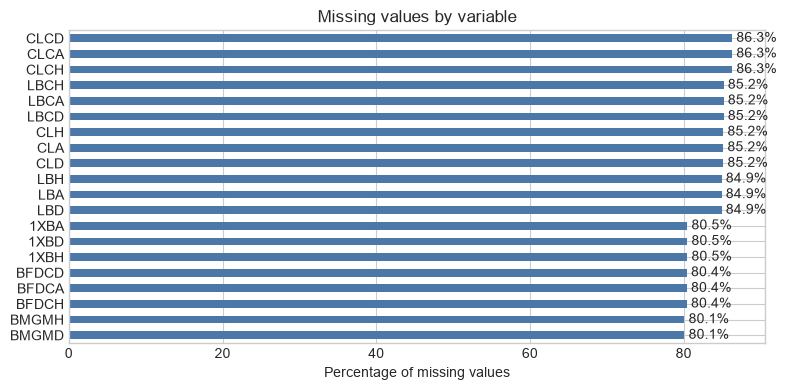

In [135]:
missing_pct = premier_df.isna().mean().mul(100).sort_values().tail(20)

fig, ax = plt.subplots(figsize=(8, 4))
missing_pct.plot(kind="barh", ax=ax, color="#4C78A8")
ax.set(title="Missing values by variable", xlabel="Percentage of missing values", ylabel="")
ax.bar_label(ax.containers[0], fmt="%.1f%%", padding=3)
plt.tight_layout()
plt.show()


- Here we can observe the distribution of missing values, which are heavily concentrated within the bookmaker features.

# 2. The target variable (the result)

In addition to analyzing the class distribution, we established a **baseline**: a naive model that consistently predicts the majority class (home win, `H`) would yield an accuracy of 44.2%. Any predictive model must outperform this threshold. Furthermore, due to the multi-class nature of the problem and the inherent class imbalance, it is advisable to evaluate performance metrics per class (home, draw, away) rather than relying solely on overall accuracy.

In [136]:
target_summary = (
    premier_df["FTR"]
    .value_counts()
    .rename(index={"H": "Home Win", "D": "Draw", "A": "Away Win"})
    .to_frame("n")
)
target_summary["pct"] = target_summary["n"].div(len(premier_df)).mul(100)
target_summary


,n,pct
FTR,,
Home Win,839,44.158
Away Win,607,31.947
Draw,454,23.895


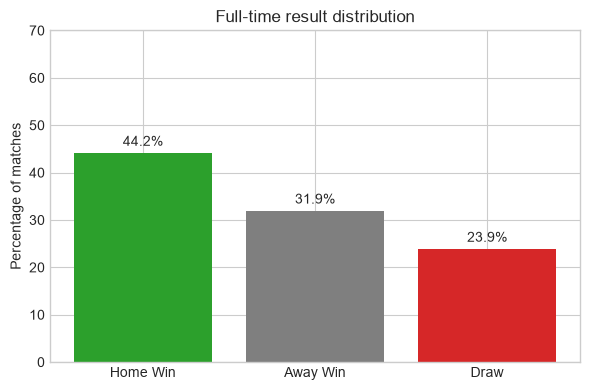

In [137]:
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(target_summary.index, target_summary["pct"], color=["#2CA02C", "#7F7F7F", "#D62728"])
ax.set(title="Full-time result distribution", ylabel="Percentage of matches", ylim=(0, 70))
ax.bar_label(bars, fmt="%.1f%%", padding=3)
plt.tight_layout()
plt.show()


### Interpretation

The analysis of the class distribution reveals a pronounced home-field advantage, with approximately 44% home wins compared to 32% away wins and 24% draws. This implies that a naive baseline model that consistently predicts a home win would yield an initial accuracy of 44.2%. Any predictive model must strictly outperform this threshold, and given the inherent class imbalance, it is imperative to evaluate performance using per-class metrics (home, draw, away) rather than relying exclusively on overall accuracy.

# 3. Categorical variables and match outcome

To avoid misleading interpretations, the following tables report the group size (`n`) and the breakdown of outcomes (`H`, `D`, `A`) together.

In [138]:

def match_outcomes_summary(data, group_cols, target_col):
    """
    Summarize the number of matches and the breakdown of outcomes (H, D, A)
    for any grouping of variables.
    """
    if isinstance(group_cols, str):
        group_cols = [group_cols]
    
    # 1. Group and count the frequencies of each class (H, D, A)
    summary = (
        data.groupby(group_cols, observed=True)[target_col]
        .value_counts()
        .unstack(fill_value=0) # Converts class rows into columns
    )
    
    # 2. Compute the total number of matches for that group
    summary["Total"] = summary.sum(axis=1)
    
    # 3. Compute percentages dynamically for each existing class
    # Use the actual classes found in the pivot table
    classes = [col for col in summary.columns if col != "Total"]
    
    for col in classes:
        summary[f"{col}_pct"] = (summary[col] / summary["Total"] * 100).round(2)
        
    return summary

# --- APPLICATION ---

# Breakdown of the final result (FTR) by Season
season_ftr_summary = match_outcomes_summary(premier_df, "Season", "FTR")

# Breakdown of the half-time result (HTR) by Season
season_htr_summary = match_outcomes_summary(premier_df, "HTR", "FTR")

referee_summary = match_outcomes_summary(premier_df, "Referee", "FTR")

home_team_summary = match_outcomes_summary(premier_df, "HomeTeam", "FTR")
away_team_summary = match_outcomes_summary(premier_df, "AwayTeam", "FTR")
division_summary = match_outcomes_summary(premier_df, "Div", "FTR")


display(season_ftr_summary)
display(season_htr_summary)
display(referee_summary)
display(home_team_summary)
display(away_team_summary)
display(division_summary)


FTR,A,D,H,Total,A_pct,D_pct,H_pct
Season,,,,,,,
2021-2022,129,88,163,380,33.950,23.160,42.890
2022-2023,109,87,184,380,28.680,22.890,48.420
2023-2024,123,82,175,380,32.370,21.580,46.050
2024-2025,132,93,155,380,34.740,24.470,40.790
2025-2026,114,104,162,380,30.000,27.370,42.630


FTR,A,D,H,Total,A_pct,D_pct,H_pct
HTR,,,,,,,
A,343,87,60,490,70.000,17.760,12.240
D,210,253,266,729,28.810,34.710,36.490
H,54,114,513,681,7.930,16.740,75.330


FTR,A,D,H,Total,A_pct,D_pct,H_pct
Referee,,,,,,,
A Kitchen,0,3,3,6,0.000,50.000,50.000
A Madley,35,23,46,104,33.650,22.120,44.230
A Marriner,16,6,10,32,50.000,18.750,31.250
A Taylor,54,39,53,146,36.990,26.710,36.300
C Kavanagh,36,28,41,105,34.290,26.670,39.050
C Pawson,40,25,44,109,36.700,22.940,40.370
D Bond,5,6,12,23,21.740,26.090,52.170
D Coote,21,16,26,63,33.330,25.400,41.270
D England,25,23,39,87,28.740,26.440,44.830


FTR,A,D,H,Total,A_pct,D_pct,H_pct
HomeTeam,,,,,,,
Arsenal,12,15,68,95,12.630,15.790,71.580
Aston Villa,22,20,53,95,23.160,21.050,55.790
Bournemouth,24,24,28,76,31.580,31.580,36.840
Brentford,27,29,39,95,28.420,30.530,41.050
Brighton,24,31,40,95,25.260,32.630,42.110
Burnley,31,17,9,57,54.390,29.820,15.790
Chelsea,22,28,45,95,23.160,29.470,47.370
Crystal Palace,28,35,32,95,29.470,36.840,33.680
Everton,38,23,34,95,40.000,24.210,35.790


FTR,A,D,H,Total,A_pct,D_pct,H_pct
AwayTeam,,,,,,,
Arsenal,54,20,21,95,56.840,21.050,22.110
Aston Villa,36,18,41,95,37.890,18.950,43.160
Bournemouth,24,20,32,76,31.580,26.320,42.110
Brentford,29,20,46,95,30.530,21.050,48.420
Brighton,32,28,35,95,33.680,29.470,36.840
Burnley,7,16,34,57,12.280,28.070,59.650
Chelsea,39,22,34,95,41.050,23.160,35.790
Crystal Palace,27,28,40,95,28.420,29.470,42.110
Everton,22,29,44,95,23.160,30.530,46.320


FTR,A,D,H,Total,A_pct,D_pct,H_pct
Div,,,,,,,
E0,607,454,839,1900,31.950,23.890,44.160


In [139]:
columns_pct = ["H_pct", "D_pct", "A_pct"]
colors = ["#2CA02C", "#7F7F7F", "#D62728"] # Green (H), Gray (D), Red (A)
legend = ["Home Win (H)", "Draw (D)", "Away Win (A)"]


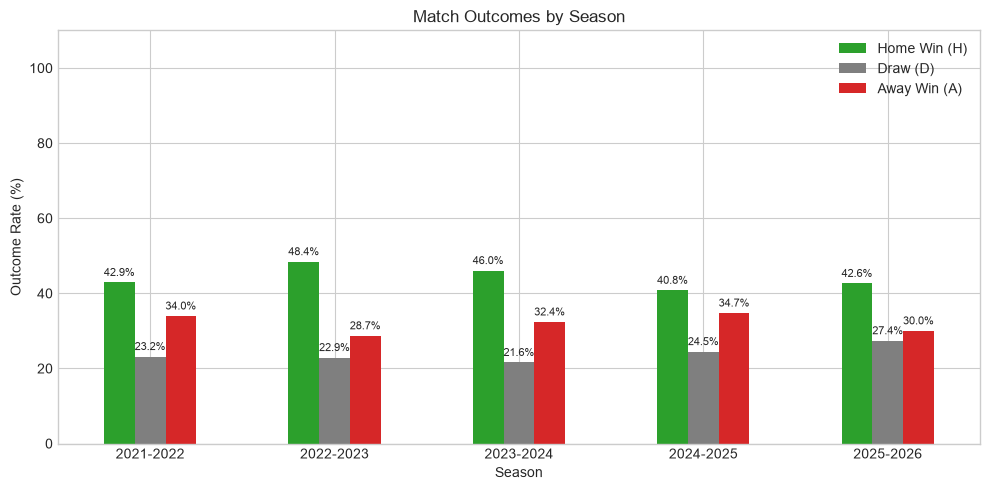

In [140]:
fig, ax = plt.subplots(figsize=(10, 5))

season_ftr_summary[ columns_pct ].plot(kind="bar", ax=ax, color=colors, rot=0)
ax.set(title="Match Outcomes by Season", xlabel="Season", ylabel="Outcome Rate (%)", ylim=(0, 110))
ax.legend(legend)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3, size=8)

plt.tight_layout()
plt.show()

### Interpretation

- **Observation:** Across the 5 seasons, the home win frequency ranges from 41% to 48%, the draw frequency from 22% to 27%, and the away win frequency from 29% to 35%. Each season comprises a sample size of 380 matches.
- **Interpretation:** The home-field advantage remains consistent year over year, with the home team continually outperforming the away team. The marginal inter-seasonal variance (fluctuations of roughly 4 percentage points) lacks statistical significance: given a sample size of 380 instances, such deviations fall strictly within the margin of error and are attributable to random noise rather than an actual underlying trend.
- **Decision/Hypothesis:** The season feature in isolation exhibits negligible predictive power. Its fundamental utility lies in structuring the dataset chronologically (e.g., implementing an out-of-time validation split by training on historical data and testing on subsequent periods) rather than serving as a robust predictive feature.


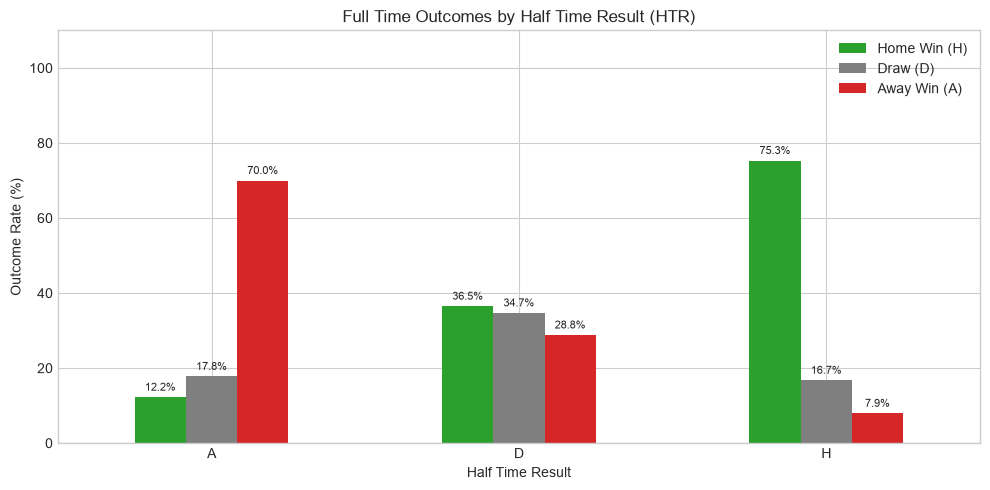

In [141]:
fig, ax = plt.subplots(figsize=(10, 5))

season_htr_summary[columns_pct].plot(kind="bar", ax=ax, color=colors, rot=0)
ax.set(title="Full Time Outcomes by Half Time Result (HTR)", xlabel="Half Time Result", ylabel="Outcome Rate (%)", ylim=(0, 110))
ax.legend(legend)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3, size=8)

plt.tight_layout()
plt.show()

### Interpretation

- **Observation:** If a team is leading at half-time, they secure the full-time victory in approximately 75% of instances. Conversely, trailing at the half results in a loss in 70% of cases. If the half-time state is a draw, the final outcome distribution is nearly uniform across all three classes.
- **Interpretation:** The half-time state is highly correlated with the final target variable. Only 25% of matches feature a comeback that overturns a favorable half-time scoreline.
- **Decision/Hypothesis:** This feature must be strictly excluded from the predictive model. Since it is recorded during the ongoing event, it remains unobservable at the time of prediction. Incorporating it as a training parameter would introduce severe **data leakage**, fundamentally invalidating the model and artificially inflating its performance metrics.


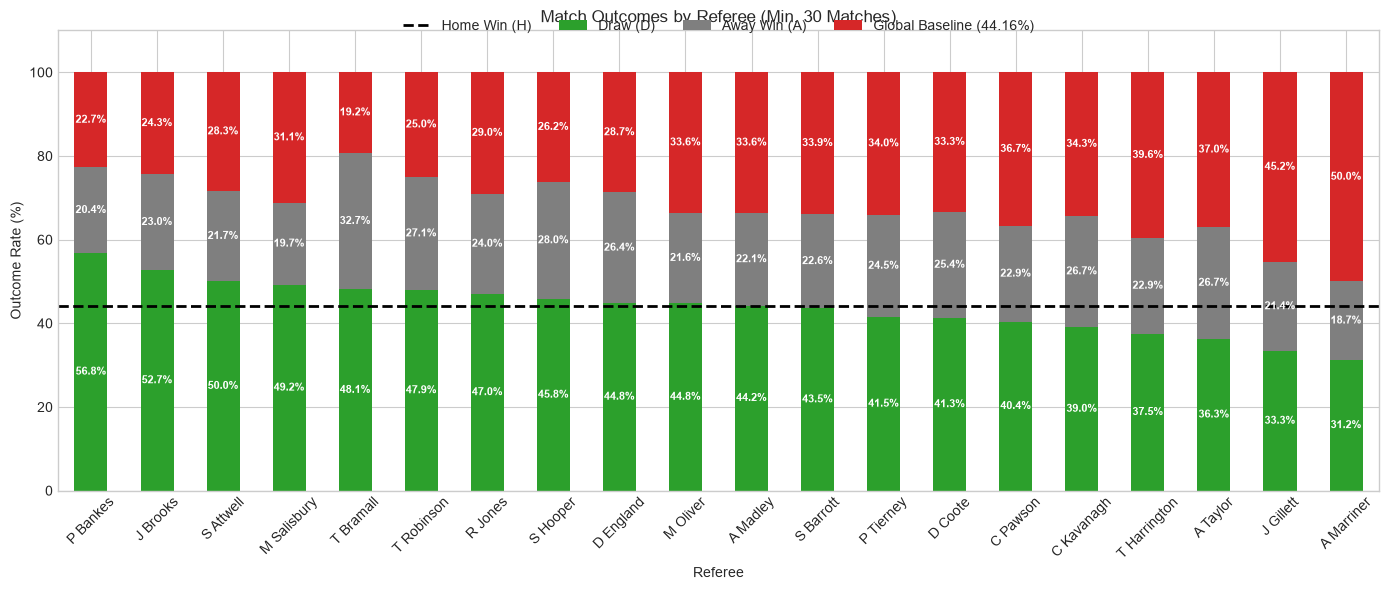

--- Referees with HIGHEST Home Win Rate ---


FTR,A,D,H,Total,A_pct,D_pct,H_pct
Referee,,,,,,,
P Bankes,20,18,50,88,22.730,20.450,56.820
J Brooks,18,17,39,74,24.320,22.970,52.700
S Attwell,30,23,53,106,28.300,21.700,50.000



--- Referees with LOWEST Home Win Rate ---


FTR,A,D,H,Total,A_pct,D_pct,H_pct
Referee,,,,,,,
A Taylor,54,39,53,146,36.990,26.710,36.300
J Gillett,38,18,28,84,45.240,21.430,33.330
A Marriner,16,6,10,32,50.000,18.750,31.250


In [142]:
# referees with at least 30 matches (for statistical significance)
referees_filtered = referee_summary[referee_summary['Total'] >= 30].copy()

referees_filtered = referees_filtered.sort_values(by="H_pct", ascending=False)

referees_plot_data = referees_filtered[["H_pct", "D_pct", "A_pct"]]

fig, ax = plt.subplots(figsize=(14, 6))

referees_plot_data.plot(kind="bar", stacked=True, ax=ax, color=colors, rot=45)

plt.axhline(y=44.16, color='black', linestyle='--', linewidth=2, label='Global Home Win Baseline (44.16%)')

ax.set(title="Match Outcomes by Referee (Min. 30 Matches)",  xlabel="Referee", ylabel="Outcome Rate (%)", ylim=(0, 110))

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, ["Home Win (H)", "Draw (D)", "Away Win (A)", "Global Baseline (44.16%)"], 
          loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=4)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", label_type='center', size=8, color='white', weight='bold')

plt.tight_layout()
plt.show()

# Inspect the extreme referees to check whether the bar-chart differences
# are plausible or just noise from small samples.
print("--- Referees with HIGHEST Home Win Rate ---")
display(referees_filtered.head(3))
print("\n--- Referees with LOWEST Home Win Rate ---")
display(referees_filtered.tail(3))


### Conclusion: Low feature importance of the referee (exclusion recommended)

- **Observation:** The outcome distributions vary across referees: some exhibit a higher frequency of home wins than others, even when filtering for those with a sample size of 30 or more matches.
- **Interpretation:** This variance does not imply causation regarding the match outcome. Referee assignment is non-random (acting as a confounding variable, e.g., certain referees are assigned to higher-tier teams), and given the high cardinality of 40 referees, some distributions will appear skewed purely due to random noise. Furthermore, the low sample size per referee results in high variance, meaning their percentages can fluctuate heavily by chance.
- **Decision/Hypothesis:** Incorporating the referee feature into the model introduces a severe risk of overfitting: the algorithm might memorize random noise rather than learning true, generalizable patterns. The optimal approach is to drop this feature entirely and retain the variables with robust predictive power (team strength and market odds).

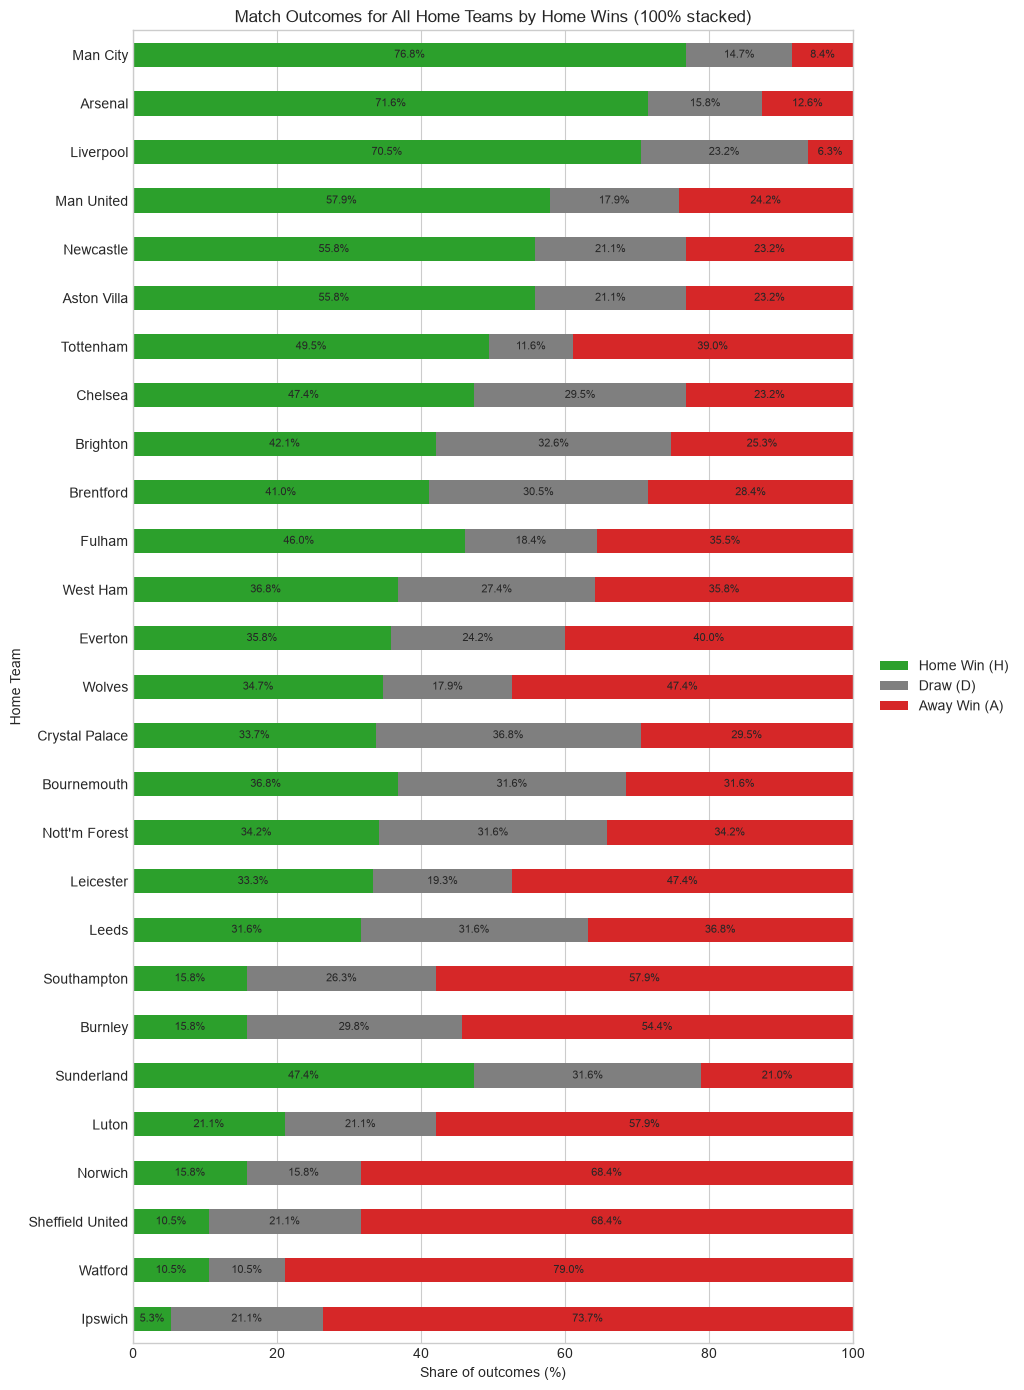

In [143]:
fig, ax = plt.subplots(figsize=(11, 14))

# All teams sorted by home wins (H): the one with the most wins on top
top_home_teams = home_team_summary.sort_values("H", ascending=False).iloc[::-1]

# One horizontal bar per team: green wins (H), red loses (A)
top_home_teams[columns_pct].plot(kind="barh", stacked=True, ax=ax, color=colors)
ax.set(title="Match Outcomes for All Home Teams by Home Wins (100% stacked)", xlabel="Share of outcomes (%)", ylabel="Home Team", xlim=(0, 100))
ax.legend(legend, loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", label_type="center", size=8)

plt.tight_layout()
fig.subplots_adjust(right=0.78)
plt.show()


### Interpretation

- **Observation:** The teams exhibit clear stratification: top-tier teams achieve a home win rate between 60% and 70%, whereas bottom-tier teams fluctuate between 20% and 30%. The global baseline stands at approximately 44%.
- **Interpretation:** The identity of the home team holds high feature importance: this stratification closely mirrors the latent team strength, clearly distinguishing elite teams from lower-tier ones. It carries significantly more predictive power than either the season or the referee features.
- **Decision/Hypothesis:** The team identity provides true signal and must be leveraged. However, directly encoding 27 distinct teams as individual categorical variables introduces high dimensionality (e.g., via one-hot encoding). A more optimal approach is to apply feature engineering to map them into a single continuous metric that quantifies team performance (such as points per game), or to rely entirely on the betting market odds, which already encapsulate this underlying strength as an aggregated proxy feature.

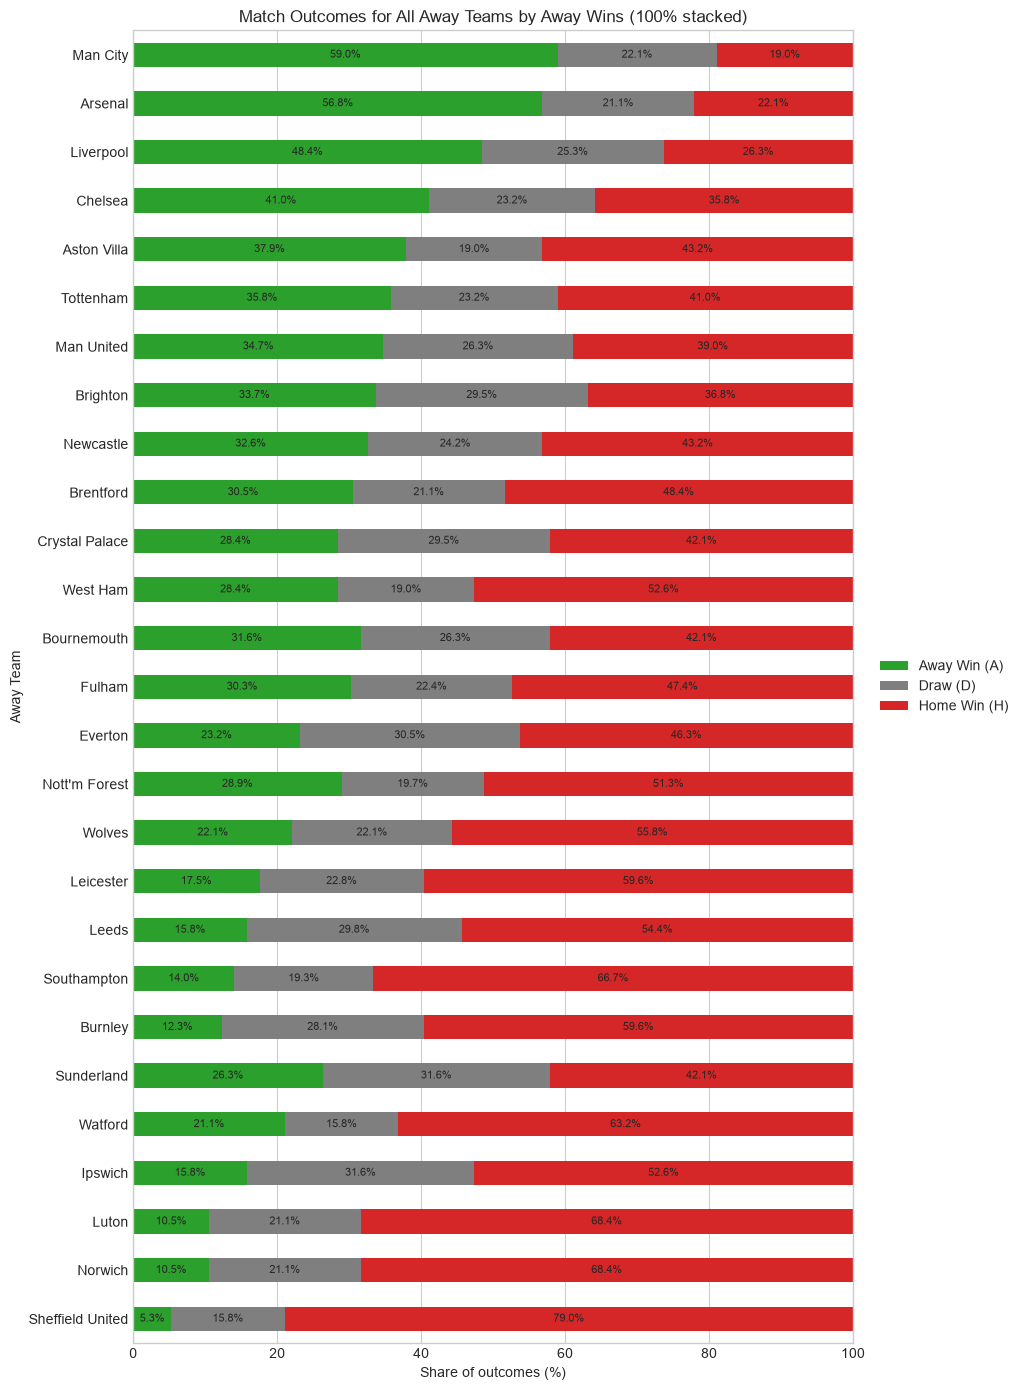

In [144]:
fig, ax = plt.subplots(figsize=(11, 14))

# All teams sorted by away wins (A): the one with the most wins on top
top_away_teams = away_team_summary.sort_values("A", ascending=False).iloc[::-1]

# Logical order for the evaluated team (away): won (A), drew (D), lost (H)
top_away_teams[["A_pct", "D_pct", "H_pct"]].plot(kind="barh", stacked=True, ax=ax, color=colors)
ax.set(title="Match Outcomes for All Away Teams by Away Wins (100% stacked)", xlabel="Share of outcomes (%)", ylabel="Away Team", xlim=(0, 100))
ax.legend(["Away Win (A)", "Draw (D)", "Home Win (H)"], loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", label_type="center", size=8)

plt.tight_layout()
fig.subplots_adjust(right=0.78)
plt.show()


### Interpretation

- **Observation:** Away teams also exhibit stratification, though the variance is heavily attenuated compared to their home fixtures: top-tier teams achieve a maximum away win rate of roughly 50%, while bottom-tier teams hover around 15%. The global baseline sits at 32%.
- **Interpretation:** Playing away acts as a dampening factor that compresses the distribution between teams: the higher difficulty of securing an away win lowers the ceiling for elite teams, grouping the overall field closer together. Despite this, the ordinal ranking of latent team strength remains consistent.
- **Decision/Hypothesis:** It is optimal to decouple "home team strength" and "away team strength" into two distinct features, given their highly asymmetric performance profiles across venues.

In [145]:
home_team_season_summary = match_outcomes_summary( premier_df, [ "HomeTeam", "Season" ], "FTR")
display(home_team_season_summary)
away_team_season_summary = match_outcomes_summary( premier_df, [ "AwayTeam", "Season" ], "FTR")
display(away_team_season_summary)


FTR                  A  D   H  Total  A_pct  D_pct  H_pct
HomeTeam Season                                          
Arsenal  2021-2022   4  2  13     19 21.050 10.530 68.420
         2022-2023   2  3  14     19 10.530 15.790 73.680
         2023-2024   2  2  15     19 10.530 10.530 78.950
         2024-2025   2  6  11     19 10.530 31.580 57.890
         2025-2026   2  2  15     19 10.530 10.530 78.950
...                 .. ..  ..    ...    ...    ...    ...
Wolves   2021-2022   9  3   7     19 47.370 15.790 36.840
         2022-2023   7  3   9     19 36.840 15.790 47.370
         2023-2024   8  3   8     19 42.110 15.790 42.110
         2024-2025  10  3   6     19 52.630 15.790 31.580
         2025-2026  11  5   3     19 57.890 26.320 15.790

[100 rows x 7 columns]

FTR                  A  D   H  Total  A_pct  D_pct  H_pct
AwayTeam Season                                          
Arsenal  2021-2022   9  1   9     19 47.370  5.260 47.370
         2022-2023  12  3   4     19 63.160 15.790 21.050
         2023-2024  13  3   3     19 68.420 15.790 15.790
         2024-2025   9  8   2     19 47.370 42.110 10.530
         2025-2026  11  5   3     19 57.890 26.320 15.790
...                 .. ..  ..    ...    ...    ...    ...
Wolves   2021-2022   8  3   8     19 42.110 15.790 42.110
         2022-2023   2  5  12     19 10.530 26.320 63.160
         2023-2024   5  4  10     19 26.320 21.050 52.630
         2024-2025   6  3  10     19 31.580 15.790 52.630
         2025-2026   0  6  13     19  0.000 31.580 68.420

[100 rows x 7 columns]

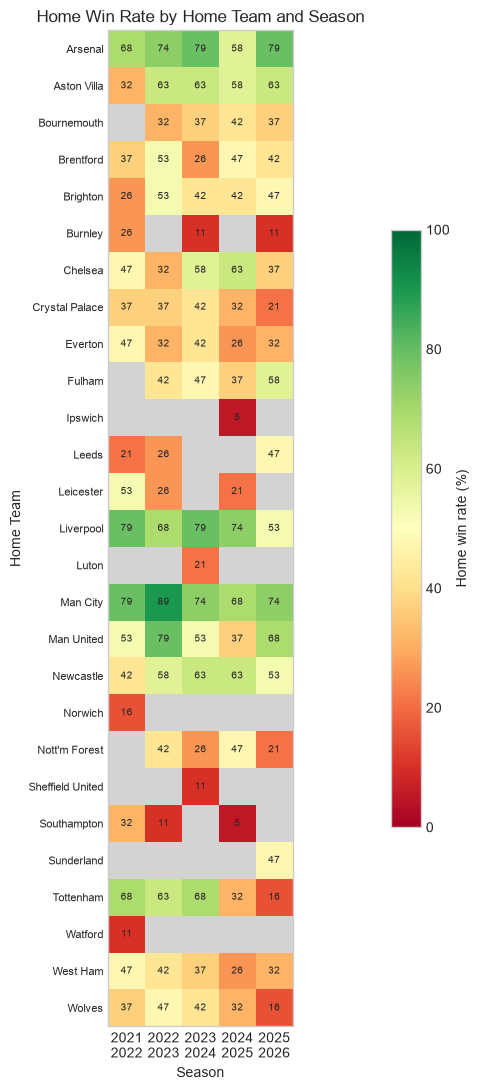

In [146]:
# Chart 1: home win rate by home team and season
home_season_pivot = home_team_season_summary["H_pct"].unstack("Season")

cmap = plt.cm.RdYlGn.copy()
cmap.set_bad("lightgray")

fig, ax = plt.subplots(figsize=(20, 11))
im = ax.imshow(home_season_pivot.values, cmap=cmap, vmin=0, vmax=100)
ax.set_xticks(range(home_season_pivot.shape[1]))
ax.set_xticklabels([c.replace("-", "\n") for c in home_season_pivot.columns], fontsize=10)
ax.set_yticks(range(home_season_pivot.shape[0]))
ax.set_yticklabels(home_season_pivot.index, fontsize=8)
ax.grid(False)
ax.set_title("Home Win Rate by Home Team and Season")
ax.set_xlabel("Season")
ax.set_ylabel("Home Team")

for i in range(home_season_pivot.shape[0]):
    for j in range(home_season_pivot.shape[1]):
        val = home_season_pivot.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"{val:.0f}", ha="center", va="center", fontsize=7)

fig.colorbar(im, ax=ax, label="Home win rate (%)", shrink=0.6)
plt.tight_layout()
plt.show()


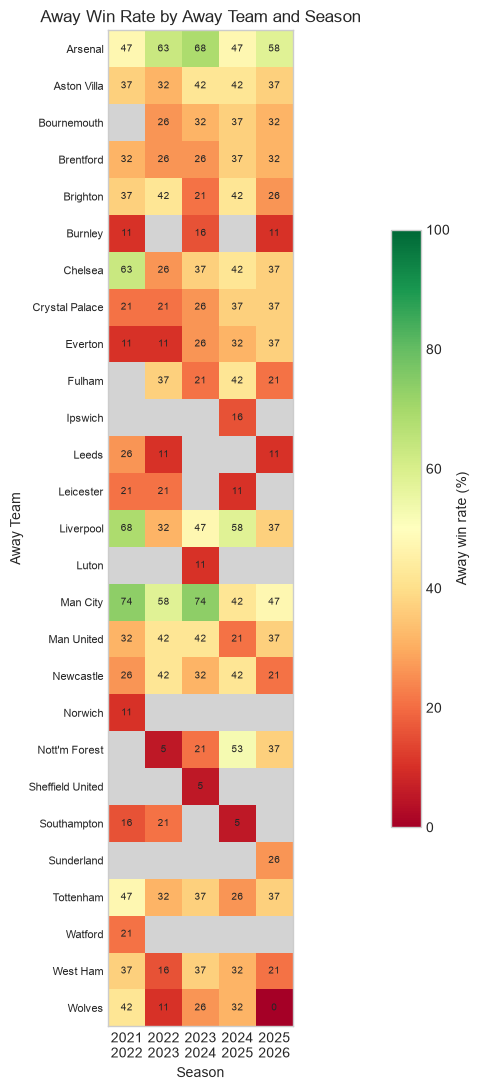

In [147]:
# Chart 2: away win rate by away team and season
away_season_pivot = away_team_season_summary["A_pct"].unstack("Season")

cmap = plt.cm.RdYlGn.copy()
cmap.set_bad("lightgray")

fig, ax = plt.subplots(figsize=(20, 11))
im = ax.imshow(away_season_pivot.values, cmap=cmap, vmin=0, vmax=100)
ax.set_xticks(range(away_season_pivot.shape[1]))
ax.set_xticklabels([c.replace("-", "\n") for c in away_season_pivot.columns], fontsize=10)
ax.set_yticks(range(away_season_pivot.shape[0]))
ax.set_yticklabels(away_season_pivot.index, fontsize=8)
ax.grid(False)
ax.set_title("Away Win Rate by Away Team and Season")
ax.set_xlabel("Season")
ax.set_ylabel("Away Team")

for i in range(away_season_pivot.shape[0]):
    for j in range(away_season_pivot.shape[1]):
        val = away_season_pivot.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"{val:.0f}", ha="center", va="center", fontsize=7)

fig.colorbar(im, ax=ax, label="Away win rate (%)", shrink=0.6)
plt.tight_layout()
plt.show()


### Interpretation (heatmaps: team per season)

- **Observation:** Within the heatmap, the most salient feature is the structural sparsity (data gaps): certain teams appear across all seasons, whereas others are present in only one or two. Each team has a fixed sample size of 19 fixtures per season.
- **Interpretation:** This structural sparsity holds high feature importance and is not missing completely at random (not MCAR): the absent entries correspond to teams relegated to a lower division. A strong correlation is evident: teams exhibiting higher seasonal sparsity generally underperform. Stratifying the teams by their league tenure reveals that teams present across all 5 seasons achieve a mean win rate of 44%, whereas those with only 1 season of presence yield a mere 17%. In other words, top-flight retention serves as a robust proxy for latent team strength.
- **Decision/Hypothesis:** The true predictive signal derived from the heatmap is not the color intensity of individual cells (which suffers from small sample sizes and high statistical noise), but rather the underlying temporal presence pattern. A team's cumulative league tenure (or a binary feature encoding recent promotion) constitutes a powerful, parsimonious feature that is strictly known prior to inference time (zero risk of data leakage). Engineering this into a core model feature is highly recommended.


# 4. Home/Away: the strongest categorical feature

Each instance inherently encodes the home-field status from the home team's perspective: `FTR = H` denotes a home win, `A` represents an away win, and `D` indicates a draw. Consequently, the empirical distribution of the target variable **is** effectively the Home/Away analysis: the *home advantage* is formally defined as the delta between P(H) and P(A).

To demonstrate that this home-field advantage is not merely a statistical artifact driven by 2-3 outlier teams, we benchmark the **home vs. away** win rate for each individual team.

In [148]:
# Build a long table: each row = a team in a match, with its venue
home_part = premier_df[["HomeTeam", "FTR"]].copy()
home_part["venue"] = "Home"
home_part["win"] = home_part["FTR"].eq("H").astype(int)
home_part["draw"] = home_part["FTR"].eq("D").astype(int)
home_part = home_part.rename(columns={"HomeTeam": "team"})

away_part = premier_df[["AwayTeam", "FTR"]].copy()
away_part["venue"] = "Away"
away_part["win"] = away_part["FTR"].eq("A").astype(int)
away_part["draw"] = away_part["FTR"].eq("D").astype(int)
away_part = away_part.rename(columns={"AwayTeam": "team"})

venue_long = pd.concat([home_part, away_part], ignore_index=True)

# Win rate and points per game (PPG) by venue
home_advantage = venue_long.groupby("venue").agg(
    n=("win", "size"),
    win_pct=("win", lambda s: s.mean() * 100),
    draw_pct=("draw", lambda s: s.mean() * 100),
).round(1)
home_advantage["ppg"] = (3 * home_advantage["win_pct"] / 100 + home_advantage["draw_pct"] / 100).round(2)
home_advantage

# Home advantage as the delta of win% and of PPG
delta_win = home_advantage.loc["Home", "win_pct"] - home_advantage.loc["Away", "win_pct"]
delta_ppg = home_advantage.loc["Home", "ppg"] - home_advantage.loc["Away", "ppg"]
print(f"Home advantage (win%): {delta_win:.1f} pp")
print(f"Home advantage (PPG):  {delta_ppg:.2f} ppg")


Home advantage (win%): 12.3 pp
Home advantage (PPG):  0.37 ppg


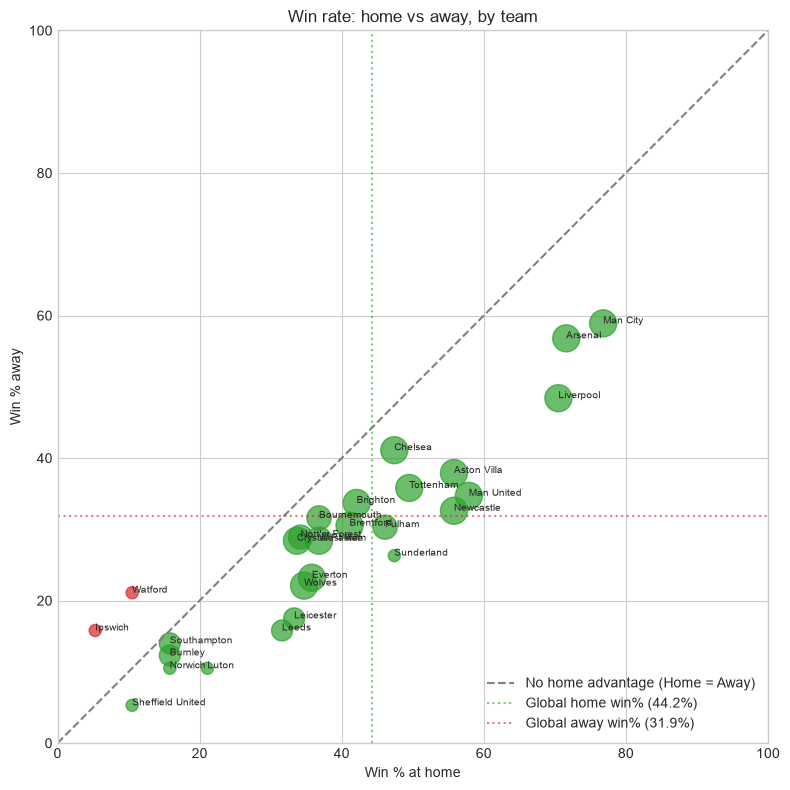

In [149]:
team_n = venue_long.groupby("team")["win"].size()

team_venue = venue_long.groupby(["team", "venue"])["win"].mean().mul(100).round(1).unstack("venue")
team_venue["n"] = team_n

home_global = home_advantage.loc["Home", "win_pct"]
away_global = home_advantage.loc["Away", "win_pct"]

fig, ax = plt.subplots(figsize=(8, 8))
color = ["#2CA02C" if h >= a else "#D62728" for h, a in zip(team_venue["Home"], team_venue["Away"])]
ax.scatter(team_venue["Home"], team_venue["Away"], s=team_venue["n"] * 2, c=color, alpha=0.7)

# References: diagonal (neutral at team level) and population center
ax.plot([0, 100], [0, 100], "--", color="gray", label="No home advantage (Home = Away)")
ax.axvline(home_global, color="#2CA02C", linestyle=":", alpha=0.6, label=f"Global home win% ({home_global:.1f}%)")
ax.axhline(away_global, color="#D62728", linestyle=":", alpha=0.6, label=f"Global away win% ({away_global:.1f}%)")

ax.set(
    title="Win rate: home vs away, by team",
    xlabel="Win % at home",
    ylabel="Win % away",
    xlim=(0, 100),
    ylim=(0, 100),
)
for team in team_venue.index:
    ax.annotate(team, (team_venue.loc[team, "Home"], team_venue.loc[team, "Away"]), fontsize=7)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


### Interpretation

- **Observation:** In the scatter plot featuring the identity line, each data point represents a unique team: the x-axis encodes the home win rate, while the y-axis encodes the away win rate. The diagonal reference line ($y = x$) serves as the parity boundary where home performance perfectly matches away performance: a data point intersecting this line would indicate absolute neutrality regarding venue.
- **Interpretation:** The overwhelming majority of the data points fall strictly below this identity line. Positioning below the boundary denotes a higher win rate at home than away. Given its prevalence across the dataset, the home-field advantage is a systemic, league-wide phenomenon rather than a statistical anomaly driven by a few outlier teams.
- **Decision/Hypothesis:** This home-field advantage can be integrated into the predictive model either as a global bias term (a constant weight added to the home team's probability) or by decoupling the latent team strength into distinct "home performance" and "away performance" features. Consequently, the high-cardinality categorical team names must be aggregated and encoded into continuous proxy metrics that quantify their underlying strength.

# 5. Numerical features: match statistics and bookmaker odds

Here we examine the numerical features, which are partitioned into two distinct subsets:

1. **Match statistics (16):** goals, shots, fouls, corner kicks, and bookings.
   These are strictly observable only **after** the match concludes.
2. **Bookmaker odds (132):** the implied probabilities priced by the betting markets
   **prior** to the match.

The core inquiry of this section is: which of these features correlate with the target variable (`FTR`) and which do not? Features observable exclusively post-match are fundamentally unviable for prediction (introducing severe data leakage); conversely, the market odds, available a priori, possess valid predictive utility.

In [150]:
# Classify the numeric columns into two blocks according to their analytical role
match_stats = ["FTHG", "FTAG", "HTHG", "HTAG", "HS", "AS", "HST", "AST",
               "HF", "AF", "HC", "AC", "HY", "AY", "HR", "AR"]

# The odds block is the remaining 132 float64 columns
odds_cols = premier_df.select_dtypes(include=["float64"]).columns.tolist()

# Summary: dtype, block, and % missing for each numeric column
num_summary = pd.DataFrame({
    "dtype": premier_df[match_stats + odds_cols].dtypes,
    "block": ["match_stats"] * len(match_stats) + ["odds"] * len(odds_cols),
    "missing_pct": premier_df[match_stats + odds_cols].isna().mean().mul(100),
}).round(2)

print(f"match_stats: {num_summary['block'].eq('match_stats').sum()} columns | "
      f"odds: {num_summary['block'].eq('odds').sum()} columns")
print(f"Mean missing in match_stats: "
      f"{num_summary.loc[num_summary['block'] == 'match_stats', 'missing_pct'].mean():.2f}%")
print(f"Mean missing in odds:        "
      f"{num_summary.loc[num_summary['block'] == 'odds', 'missing_pct'].mean():.2f}%")
num_summary.head(20)


match_stats: 16 columns | odds: 132 columns
Mean missing in match_stats: 0.00%
Mean missing in odds:        34.45%


,dtype,block,missing_pct
FTHG,int64,match_stats,0.000
FTAG,int64,match_stats,0.000
HTHG,int64,match_stats,0.000
HTAG,int64,match_stats,0.000
HS,int64,match_stats,0.000
AS,int64,match_stats,0.000
HST,int64,match_stats,0.000
AST,int64,match_stats,0.000
HF,int64,match_stats,0.000
AF,int64,match_stats,0.000


### Match statistics constitute "cheating" (Data Leakage)

The target variable is a deterministic function of the goals: if the home team scores more, `FTR = H`; if they draw, `D`; if the away team scores more, `A`. Therefore, if a model were to utilize `FTHG` and `FTAG` as predictive features, it would be directly copying the target label rather than learning underlying patterns.

The same principle applies, albeit less directly, to the rest of the match statistics (shots, corner kicks, bookings): they are strictly observable only after the final whistle. **They are fundamentally useless for a pre-match predictive model.**

In [151]:
# Descriptives of the match_stats block (none missing: count = 1900 in all 16)
premier_df[match_stats].describe().T


,count,mean,std,min,25%,50%,75%,max
FTHG,1900.000,1.597,1.318,0.000,1.000,1.000,2.000,9.000
FTAG,1900.000,1.329,1.204,0.000,0.000,1.000,2.000,8.000
HTHG,1900.000,0.724,0.849,0.000,0.000,1.000,1.000,5.000
HTAG,1900.000,0.577,0.791,0.000,0.000,0.000,1.000,5.000
HS,1900.000,14.159,5.657,1.000,10.000,14.000,18.000,36.000
AS,1900.000,11.711,5.171,1.000,8.000,11.000,15.000,37.000
HST,1900.000,4.872,2.568,0.000,3.000,5.000,6.000,16.000
AST,1900.000,4.121,2.374,0.000,2.000,4.000,5.000,15.000
HF,1900.000,10.568,3.419,1.000,8.000,10.000,13.000,23.000
AF,1900.000,10.941,3.577,1.000,8.000,11.000,13.000,25.000


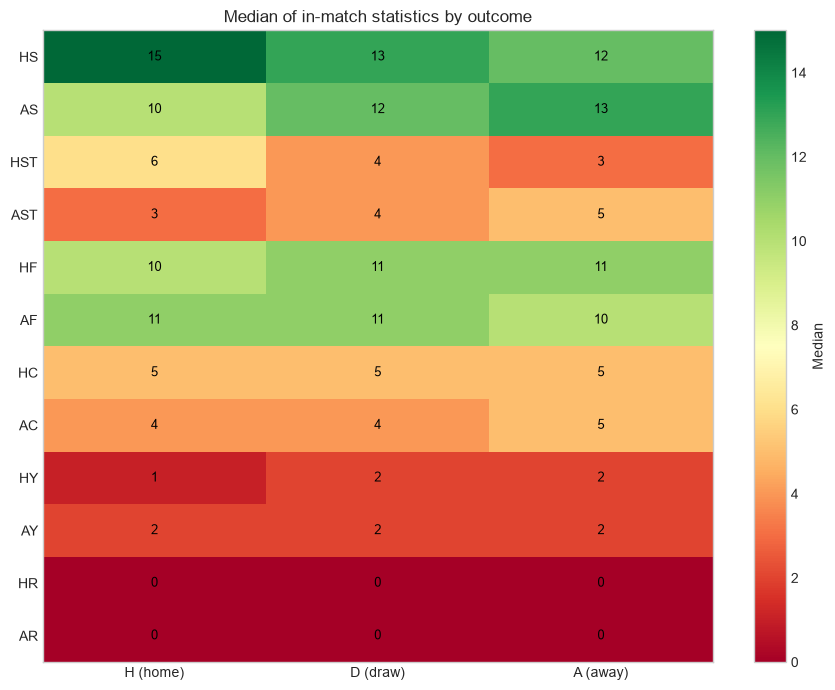

Separation |Median H - Median A| per statistic:
HS    3.000
AS    3.000
HST   3.000
AST   2.000
HF    1.000
AF    1.000
AC    1.000
HY    1.000
HC    0.000
AY    0.000
HR    0.000
AR    0.000


In [152]:
# Median of each in-match statistic by outcome (H/D/A) — heatmap
stats_12 = ["HS", "AS", "HST", "AST", "HF", "AF", "HC", "AC", "HY", "AY", "HR", "AR"]

medians = premier_df.groupby("FTR")[stats_12].median().reindex(["H", "D", "A"]).T
medians = medians.round(1)

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(medians.values, cmap="RdYlGn", vmin=0, vmax=medians.values.max(), aspect="auto")
ax.grid(False)
ax.set_xticks(range(3))
ax.set_xticklabels(["H (home)", "D (draw)", "A (away)"])
ax.set_yticks(range(len(stats_12)))
ax.set_yticklabels(stats_12)

for i in range(medians.shape[0]):
    for j in range(medians.shape[1]):
        ax.text(j, i, f"{medians.values[i, j]:.0f}", ha="center", va="center",
                fontsize=9, color="black")

fig.colorbar(im, ax=ax, label="Median")
ax.set_title("Median of in-match statistics by outcome")
plt.tight_layout()
plt.show()

# Separation signal: |median H - median A| per statistic
separation = (medians["H"] - medians["A"]).abs().sort_values(ascending=False)
print("Separation |Median H - Median A| per statistic:")
print(separation.to_string())


### Feature dictionary (Match Statistics)

| Feature | Description |
|---|---|
| `FTHG` / `FTAG` | Full-time home / away goals |
| `HTHG` / `HTAG` | Half-time home / away goals |
| `HS` / `AS` | Total home / away shots |
| `HST` / `AST` | Home / away shots **on target** (shots directed inside the frame requiring goalkeeper intervention) |
| `HF` / `AF` | Fouls committed by the home / away team |
| `HC` / `AC` | Corner kicks awarded to the home / away team |
| `HY` / `AY` | Yellow cards given to the home / away team |
| `HR` / `AR` | Red cards given to the home / away team |

The key heuristic for feature interpretation: a team demonstrates spatial dominance when they generate a higher volume of total shots, shots **on target**, and force more corner kicks in the opponent's half. Conversely, fouls and disciplinary bookings lack positive correlation with overall team performance quality (they are frequently committed by the trailing team).

### What do the post-match statistics reveal?

These features possess no validity for **prediction** (they are strictly observable post-match; incorporating them introduces severe data leakage), but they are highly valuable for the **descriptive analysis** of the event.

The preceding heatmap illustrates this:

- **Shots on target** (`HST`, `AST`) capture the variance of the target variable: the median during a home win is 6, compared to 3 during a loss. A victory strongly correlates with the generation of a higher volume of high-probability scoring chances.
- **Fouls, corner kicks, and bookings** (`HF`, `HC`, `HY`, `HR`) exhibit a near-uniform distribution across all three target classes: they hold no explanatory power regarding the match outcome.

Consequently, these metrics are strictly useful for post-hoc analysis (e.g., "the loss is attributable to a low volume of shots on target"), but **unviable for forecasting future observations**. For predictive modeling, only the market odds published *a priori* serve as valid features.

### From odds to implied probability

Decimal odds of `2.00` dictate that a successful 1-unit wager yields a payout of 2 units. Consequently, the bookmaker assigns this outcome an implied probability of `1/2 = 50%`.

However, bookmakers incorporate a margin (known as the overround or vigorish): summing the implied probabilities of the three mutually exclusive outcomes (H, D, A) yields a sum strictly greater than 100%. This excess represents the bookmaker's built-in profit margin. To benchmark the odds against the empirical outcomes, we remove this margin by normalizing the data: dividing each `1/odds` value by the sum of all three inverse odds. This normalization ensures the probability distribution sums exactly to 100%, enabling a direct comparison against the ground truth labels.

In [153]:
# Overround: 1/H + 1/D + 1/A. If the market were "fair" it would sum to 1.0;
# the excess over 1.0 is the bookmaker's margin.
odds_df = premier_df[["B365H", "B365D", "B365A", "AvgH", "AvgD", "AvgA"]].copy()
odds_df["overround_B365"] = 1/odds_df["B365H"] + 1/odds_df["B365D"] + 1/odds_df["B365A"]
odds_df["overround_Avg"]  = 1/odds_df["AvgH"]  + 1/odds_df["AvgD"]  + 1/odds_df["AvgA"]

odds_df[["overround_B365", "overround_Avg"]].agg(["mean", "min", "max"]).round(4)


,overround_B365,overround_Avg
mean,1.054,1.045
min,1.033,1.034
max,1.167,1.073


In [154]:
def implied_prob(h, d, a):
    """Convert profit odds into normalized probabilities (without overround)."""
    raw = 1/h + 1/d + 1/a
    return 1/h / raw, 1/d / raw, 1/a / raw

# Apply the function to B365 and to Avg on a temporary DataFrame (we don't touch premier_df)
probs_df = premier_df[["B365H", "B365D", "B365A", "AvgH", "AvgD", "AvgA", "FTR"]].copy()
probs_df[["pB365_H", "pB365_D", "pB365_A"]] = probs_df.apply(
    lambda r: implied_prob(r["B365H"], r["B365D"], r["B365A"]), axis=1, result_type="expand")
probs_df[["pAvg_H", "pAvg_D", "pAvg_A"]] = probs_df.apply(
    lambda r: implied_prob(r["AvgH"], r["AvgD"], r["AvgA"]), axis=1, result_type="expand")

# Sanity check: each row must sum to 1.0
print("Row sum (should be 1.0):")
print(probs_df[["pB365_H", "pB365_D", "pB365_A"]].sum(axis=1).describe().round(6))
probs_df[["pB365_H", "pAvg_H"]].describe().T.round(4)


Row sum (should be 1.0):
count   1900.000
mean       1.000
std        0.000
min        1.000
25%        1.000
50%        1.000
75%        1.000
max        1.000
dtype: float64


,count,mean,std,min,25%,50%,75%,max
pB365_H,1900.000,0.440,0.192,0.050,0.292,0.426,0.580,0.894
pAvg_H,1900.000,0.441,0.193,0.053,0.294,0.424,0.581,0.899


Baseline (always home): 44.2%


,bookmaker,n,hit_open,miss_open,hit_close,miss_close,delta
0,B365,1900,55.300,44.700,55.900,44.100,0.600
7,Avg,1900,55.300,44.700,55.900,44.100,0.600
6,Max,1900,55.200,44.800,55.700,44.300,0.600
1,BW,1747,55.200,44.800,55.500,44.500,0.300
3,PS,1730,56.100,43.900,56.400,43.600,0.200
5,BV,1510,55.600,44.400,55.700,44.300,0.100
4,WH,1429,56.800,43.200,57.000,43.000,0.300
2,IW,955,57.200,42.800,57.400,42.600,0.200


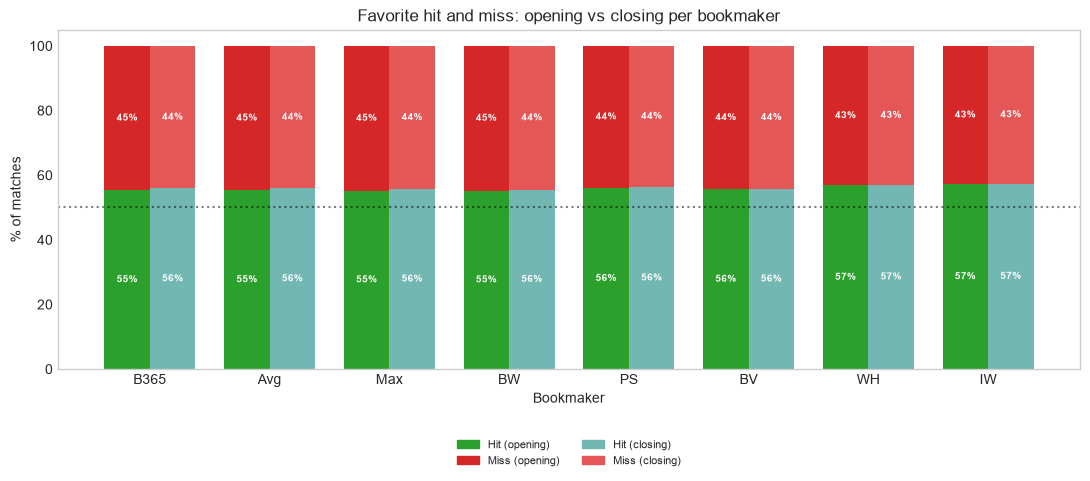

In [155]:
# Opening vs closing: when does the bookmaker get it right and when does it miss?
# Opening = odds published days before. Closing = odds right before kickoff.
# For each bookmaker, we measure hit and miss with opening and with closing.
bookmakers = {
    "B365": ("B365H","B365D","B365A","B365CH","B365CD","B365CA"),
    "BW":   ("BWH","BWD","BWA","BWCH","BWCD","BWCA"),
    "IW":   ("IWH","IWD","IWA","IWCH","IWCD","IWCA"),
    "PS":   ("PSH","PSD","PSA","PSCH","PSCD","PSCA"),
    "WH":   ("WHH","WHD","WHA","WHCH","WHCD","WHCA"),
    "BV":   ("BVH","BVD","BVA","BVCH","BVCD","BVCA"),
    "Max":  ("MaxH","MaxD","MaxA","MaxCH","MaxCD","MaxCA"),
    "Avg":  ("AvgH","AvgD","AvgA","AvgCH","AvgCD","AvgCA"),
}

rows = []
for bookmaker, (h, d, a, ch, cd, ca) in bookmakers.items():
    sub = premier_df[[h, d, a, ch, cd, ca, "FTR"]].dropna().copy()
    fav_op = sub[[h, d, a]].idxmin(axis=1).map({h: "H", d: "D", a: "A"})
    fav_cl = sub[[ch, cd, ca]].idxmin(axis=1).map({ch: "H", cd: "D", ca: "A"})
    hit_open = (fav_op == sub["FTR"]).mean() * 100
    hit_close = (fav_cl == sub["FTR"]).mean() * 100
    rows.append({"bookmaker": bookmaker, "n": len(sub),
                 "hit_open": round(hit_open, 1), "miss_open": round(100 - hit_open, 1),
                 "hit_close": round(hit_close, 1), "miss_close": round(100 - hit_close, 1),
                 "delta": round(hit_close - hit_open, 1)})

summary = pd.DataFrame(rows).sort_values("n", ascending=False)
print("Baseline (always home): %.1f%%" % (premier_df["FTR"].eq("H").mean() * 100))
display(summary)

# Chart: side-by-side stacked bars (green=hit, red=miss) × 2 (opening, closing)
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(summary))
width = 0.38
ax.grid(False)

# Opening: green below, red above
b_op_a = ax.bar(x - width/2, summary["hit_open"], width, color="#2CA02C")
b_op_f = ax.bar(x - width/2, summary["miss_open"], width, bottom=summary["hit_open"], color="#D62728")
# Closing: green below, red above
b_cl_a = ax.bar(x + width/2, summary["hit_close"], width, color="#72B7B2")
b_cl_f = ax.bar(x + width/2, summary["miss_close"], width, bottom=summary["hit_close"], color="#E45756")

# % labels inside each segment
for i in range(len(summary)):
    ax.text(x[i] - width/2, summary["hit_open"].iloc[i]/2, f"{summary['hit_open'].iloc[i]:.0f}%",
            ha="center", va="center", fontsize=7, color="white", weight="bold")
    ax.text(x[i] - width/2, summary["hit_open"].iloc[i] + summary["miss_open"].iloc[i]/2,
            f"{summary['miss_open'].iloc[i]:.0f}%", ha="center", va="center", fontsize=7, color="white", weight="bold")
    ax.text(x[i] + width/2, summary["hit_close"].iloc[i]/2, f"{summary['hit_close'].iloc[i]:.0f}%",
            ha="center", va="center", fontsize=7, color="white", weight="bold")
    ax.text(x[i] + width/2, summary["hit_close"].iloc[i] + summary["miss_close"].iloc[i]/2,
            f"{summary['miss_close'].iloc[i]:.0f}%", ha="center", va="center", fontsize=7, color="white", weight="bold")

ax.axhline(50, color="black", linestyle=":", alpha=0.5)
ax.set_xticks(x)
ax.set_xticklabels(summary["bookmaker"])
ax.set(xlabel="Bookmaker", ylabel="% of matches", ylim=(0, 105),
       title="Favorite hit and miss: opening vs closing per bookmaker")
handles = [plt.Rectangle((0,0),1,1,color=c) for c in ["#2CA02C","#D62728","#72B7B2","#E45756"]]
labels = ["Hit (opening)", "Miss (opening)", "Hit (closing)", "Miss (closing)"]
ax.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=2, frameon=False, fontsize=8)
plt.tight_layout()
plt.show()


### Higher predictive accuracy for decisive outcomes

As illustrated, the predictive accuracy derived from the bookmakers' implied probabilities exceeds 55% across the majority of the markets specifically focusing on the 8 bookmaker features consistently present across all seasons. Furthermore, instances of misclassification do not necessarily indicate a fundamental failure of the predictive signal. Often, these errors occur when the match culminates in a draw; in such scenarios, the binary prediction paradigm is disrupted, and the prediction remains unresolved, as the event converges to a neutral state where neither team formally 'wins' nor 'loses'.

### Closing odds yield equal or superior predictive accuracy compared to opening odds

- **Observation:** Across the 8 bookmakers with complete data coverage, the **closing** odds (immediately prior to kickoff) demonstrate equal or marginally superior predictive accuracy compared to the opening odds: B365 55.3→55.9 (+0.6), Avg 55.3→55.9 (+0.6), BW 55.2→55.5 (+0.3), WH 56.8→57.0 (+0.3). No bookmaker exhibits performance degradation at the closing line. Misclassification rates (red) decrease proportionally.
- **Interpretation:** The betting market continuously calibrates the implied probability between the opening and closing lines by pricing in novel data (e.g., injuries, starting XI, market liquidity), although the overall variance is minimal (~0.5 percentage points on average). The opening line already acts as a highly robust predictor, performing nearly on par with the closing line.
- **Decision/Hypothesis:** Utilize the **closing** odds (`*C`) as primary model features, given their higher information gain. The opening odds serve as a near-equivalent fallback substitute in scenarios where closing data is subject to missingness.

Baseline (always home): 44.2%


,cat,n,hit_open,hit_close,miss_open,miss_close,delta
0,Unlikely case (<1.5),465,74.200,74.200,25.800,25.800,0.000
1,Sure contender (1.5-2),679,55.700,55.700,44.300,44.300,0.000
2,Close match (2-3),756,43.400,45.000,56.600,55.000,1.600


Matches with data from all 8 bookmakers: 956
Agreement among the 8 bookmakers: 83% all, 91% 7+, 95% 6+


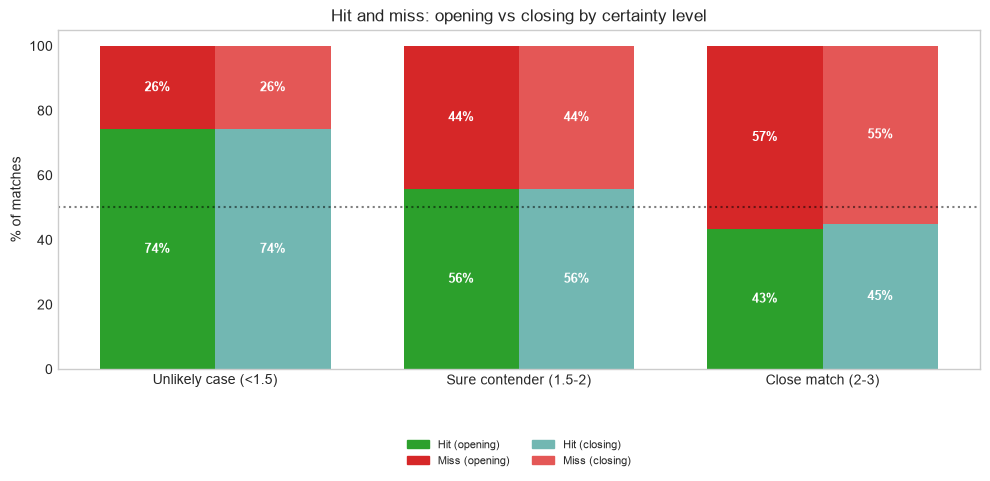

In [156]:
# Overall: opening vs closing according to the match certainty level
# We use Avg (average market). We classify by the OPENING favorite's odds
# into 3 categories, and measure hit and miss with opening and with closing.
complete_bookmakers = {
    "B365": ("B365H","B365D","B365A","B365CH","B365CD","B365CA"),
    "BW":   ("BWH","BWD","BWA","BWCH","BWCD","BWCA"),
    "IW":   ("IWH","IWD","IWA","IWCH","IWCD","IWCA"),
    "PS":   ("PSH","PSD","PSA","PSCH","PSCD","PSCA"),
    "WH":   ("WHH","WHD","WHA","WHCH","WHCD","WHCA"),
    "BV":   ("BVH","BVD","BVA","BVCH","BVCD","BVCA"),
    "Max":  ("MaxH","MaxD","MaxA","MaxCH","MaxCD","MaxCA"),
    "Avg":  ("AvgH","AvgD","AvgA","AvgCH","AvgCD","AvgCA"),
}

sub = premier_df[["AvgH","AvgD","AvgA","AvgCH","AvgCD","AvgCA","FTR"]].dropna().copy()
sub["cat"] = pd.cut(sub[["AvgH","AvgD","AvgA"]].min(axis=1),
                     bins=[1, 1.5, 2, 3],
                     labels=["Unlikely case (<1.5)", "Sure contender (1.5-2)", "Close match (2-3)"],
                     include_lowest=True)
fav_op = sub[["AvgH","AvgD","AvgA"]].idxmin(axis=1).map({"AvgH":"H","AvgD":"D","AvgA":"A"})
fav_cl = sub[["AvgCH","AvgCD","AvgCA"]].idxmin(axis=1).map({"AvgCH":"H","AvgCD":"D","AvgCA":"A"})
sub["hit_open"] = (fav_op == sub["FTR"]).astype(int)
sub["hit_close"] = (fav_cl == sub["FTR"]).astype(int)

aggregated = sub.groupby("cat", observed=True).agg(
    n=("hit_open", "size"),
    hit_open=("hit_open", lambda x: round(x.mean() * 100, 1)),
    hit_close=("hit_close", lambda x: round(x.mean() * 100, 1)),
).reset_index()
aggregated["miss_open"] = (100 - aggregated["hit_open"]).round(1)
aggregated["miss_close"] = (100 - aggregated["hit_close"]).round(1)
aggregated["delta"] = (aggregated["hit_close"] - aggregated["hit_open"]).round(1)
print("Baseline (always home): %.1f%%" % (premier_df["FTR"].eq("H").mean() * 100))
display(aggregated)

# Agreement among bookmakers (only in matches where all 8 have data)
cats_matrix = pd.DataFrame({
    bookmaker: pd.cut(premier_df[[h, d, a]].min(axis=1), bins=[1, 1.5, 2, 3],
                 labels=["Unlikely case (<1.5)", "Sure contender (1.5-2)", "Close match (2-3)"],
                 include_lowest=True)
    for bookmaker, (h, d, a, _, _, _) in complete_bookmakers.items()
})
cats_complete = cats_matrix.dropna()
mode_val = cats_complete.mode(axis=1).iloc[:, 0]
agree_pct = cats_complete.eq(mode_val, axis=0).sum(axis=1)
print("Matches with data from all 8 bookmakers: %d" % len(cats_complete))
print("Agreement among the 8 bookmakers: %.0f%% all, %.0f%% 7+, %.0f%% 6+" %
      ((agree_pct == 8).mean() * 100,
       (agree_pct >= 7).mean() * 100,
       (agree_pct >= 6).mean() * 100))

# Chart: side-by-side stacked bars per category
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(aggregated))
width = 0.38
ax.grid(False)

# Opening
b_op_a = ax.bar(x - width/2, aggregated["hit_open"], width, color="#2CA02C")
b_op_f = ax.bar(x - width/2, aggregated["miss_open"], width, bottom=aggregated["hit_open"], color="#D62728")
# Closing
b_cl_a = ax.bar(x + width/2, aggregated["hit_close"], width, color="#72B7B2")
b_cl_f = ax.bar(x + width/2, aggregated["miss_close"], width, bottom=aggregated["hit_close"], color="#E45756")

for i in range(len(aggregated)):
    ax.text(x[i] - width/2, aggregated["hit_open"].iloc[i]/2, f"{aggregated['hit_open'].iloc[i]:.0f}%",
            ha="center", va="center", fontsize=9, color="white", weight="bold")
    ax.text(x[i] - width/2, aggregated["hit_open"].iloc[i] + aggregated["miss_open"].iloc[i]/2,
            f"{aggregated['miss_open'].iloc[i]:.0f}%", ha="center", va="center", fontsize=9, color="white", weight="bold")
    ax.text(x[i] + width/2, aggregated["hit_close"].iloc[i]/2, f"{aggregated['hit_close'].iloc[i]:.0f}%",
            ha="center", va="center", fontsize=9, color="white", weight="bold")
    ax.text(x[i] + width/2, aggregated["hit_close"].iloc[i] + aggregated["miss_close"].iloc[i]/2,
            f"{aggregated['miss_close'].iloc[i]:.0f}%", ha="center", va="center", fontsize=9, color="white", weight="bold")

ax.axhline(50, color="black", linestyle=":", alpha=0.5)
ax.set_xticks(x)
ax.set_xticklabels(aggregated["cat"], fontsize=10)
ax.set(xlabel="", ylabel="% of matches", ylim=(0, 105),
       title="Hit and miss: opening vs closing by certainty level")
handles = [plt.Rectangle((0,0),1,1,color=c) for c in ["#2CA02C","#D62728","#72B7B2","#E45756"]]
labels = ["Hit (opening)", "Miss (opening)", "Hit (closing)", "Miss (closing)"]
ax.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=2, frameon=False, fontsize=8)
plt.tight_layout()
plt.show()


### The closing line improves predictive accuracy in tightly contested matches

- **Observation:** Across the 3 strata, the closing line **matches or outperforms** the opening line. The evenly matched fixtures (odds ranging 2.0-3.0) exhibit the most noticeable information gain: predictive accuracy improves from 43% to 45% (+1.6pp), while the misclassification rate drops from 57% to 55%. In the other two categories, the delta is ~0, as the opening odds were already highly calibrated.
- **Interpretation:** The market reduces entropy and achieves better calibration in fixtures where the initial uncertainty regarding the outcome was highest. In clear-cut matches, the odds barely fluctuate because the *a priori* pricing was already optimal from inception.
- **Decision/Hypothesis:** Utilize the **closing** odds (`*C`) as core model features. The opening line serves as a near-equivalent proxy and is viable as a fallback alternative if closing data is missing; nevertheless, these closing metrics yield a superior predictive signal specifically when the fixture involves teams of equal latent strength, even if the overall shift remains marginal.

### Not all bookmakers exhibit complete seasonal data coverage

A significant proportion of the missing data within the odds features does not constitute a random error (not MCAR): rather, it is a case of structural missingness because **the bookmaker did not operate** during that specific season. `B365`, `Max`, and `Avg` maintain complete temporal coverage across all 5 seasons; whereas others are present in merely 1 or 2. For instance, `CL` and `LB` exclusively contain observations from the 2025-26 season.

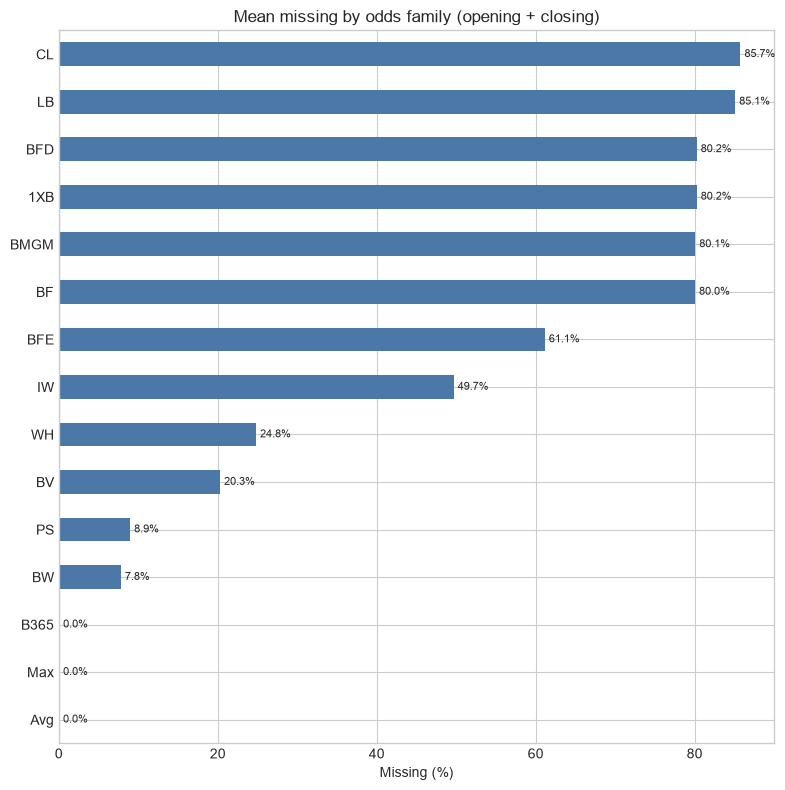

In [157]:
# Mean missing by odds family (grouped by the opening bookmaker and its "C" variant)
families = {
    "B365": ["B365H", "B365D", "B365A", "B365>2.5", "B365<2.5", "B365AHH", "B365AHA",
             "B365CH", "B365CD", "B365CA", "B365C>2.5", "B365C<2.5", "B365CAHH", "B365CAHA"],
    "BW":   ["BWH", "BWD", "BWA", "BWCH", "BWCD", "BWCA"],
    "IW":   ["IWH", "IWD", "IWA", "IWCH", "IWCD", "IWCA"],
    "PS":   ["PSH", "PSD", "PSA", "PSCH", "PSCD", "PSCA"],
    "WH":   ["WHH", "WHD", "WHA", "WHCH", "WHCD", "WHCA"],
    "BV":   ["BVH", "BVD", "BVA", "BVCH", "BVCD", "BVCA"],
    "Max":  ["MaxH", "MaxD", "MaxA", "Max>2.5", "Max<2.5", "MaxAHH", "MaxAHA",
             "MaxCH", "MaxCD", "MaxCA", "MaxC>2.5", "MaxC<2.5", "MaxCAHH", "MaxCAHA"],
    "Avg":  ["AvgH", "AvgD", "AvgA", "Avg>2.5", "Avg<2.5", "AvgAHH", "AvgAHA",
             "AvgCH", "AvgCD", "AvgCA", "AvgC>2.5", "AvgC<2.5", "AvgCAHH", "AvgCAHA"],
    "BF":   ["BFH", "BFD", "BFA", "BFCH", "BFCD", "BFCA"],
    "1XB":  ["1XBH", "1XBD", "1XBA", "1XBCH", "1XBCD", "1XBCA"],
    "BFE":  ["BFEH", "BFED", "BFEA", "BFE>2.5", "BFE<2.5", "BFEAHH", "BFEAHA",
             "BFECH", "BFECD", "BFECA", "BFEC>2.5", "BFEC<2.5", "BFECAHH", "BFECAHA"],
    "BFD":  ["BFDH", "BFDD", "BFDA", "BFDCH", "BFDCD", "BFDCA"],
    "BMGM": ["BMGMH", "BMGMD", "BMGMA", "BMGMCH", "BMGMCD", "BMGMCA"],
    "CL":   ["CLH", "CLD", "CLA", "CLCH", "CLCD", "CLCA"],
    "LB":   ["LBH", "LBD", "LBA", "LBCH", "LBCD", "LBCA"],
}

missing_family = pd.DataFrame({
    fam: premier_df[cols].isna().mean().mul(100).mean()
    for fam, cols in families.items()
}, index=["missing_pct"]).T.sort_values("missing_pct")

fig, ax = plt.subplots(figsize=(8, 8))
missing_family["missing_pct"].plot(kind="barh", ax=ax, color="#4C78A8")
ax.bar_label(ax.containers[0], fmt="%.1f%%", padding=3, size=8)
ax.set(xlabel="Missing (%)", title="Mean missing by odds family (opening + closing)")
plt.tight_layout()
plt.show()


In [158]:
# Coverage by season: % of non-null rows of a representative column per bookmaker
rep_cols = ["B365H", "BWH", "IWH", "PSH", "WHH", "BVH", "BFH", "1XBH",
            "BFEH", "CLH", "LBH", "BFDH", "BMGMH"]

coverage_table = (premier_df.groupby("Season")[rep_cols]
                   .apply(lambda g: g.notna().mean().mul(100).round(1)).T)
coverage_table


Season,2021-2022,2022-2023,2023-2024,2024-2025,2025-2026
B365H,100.000,100.000,100.000,100.000,100.000
BWH,100.000,100.000,99.500,62.900,100.000
IWH,100.000,100.000,52.100,0.000,0.000
PSH,100.000,100.000,100.000,100.000,55.300
WHH,100.000,100.000,100.000,76.100,0.000
BVH,100.000,100.000,100.000,0.000,99.500
BFH,0.000,0.000,0.000,99.700,0.000
1XBH,0.000,0.000,0.000,97.600,0.000
BFEH,0.000,0.000,0.000,100.000,94.700
CLH,0.000,0.000,0.000,0.000,74.200


### High collinearity across bookmakers

Bookmakers calibrate their odds by observing the same underlying market; consequently, their pricing should be highly correlated. Given this premise, retaining all 132 features is redundant and introduces multicollinearity: aggregating the data via the market average (`Avg`), the maximum value (`Max`), and a baseline reference bookmaker (`B365`) is strictly sufficient to capture the predictive signal.

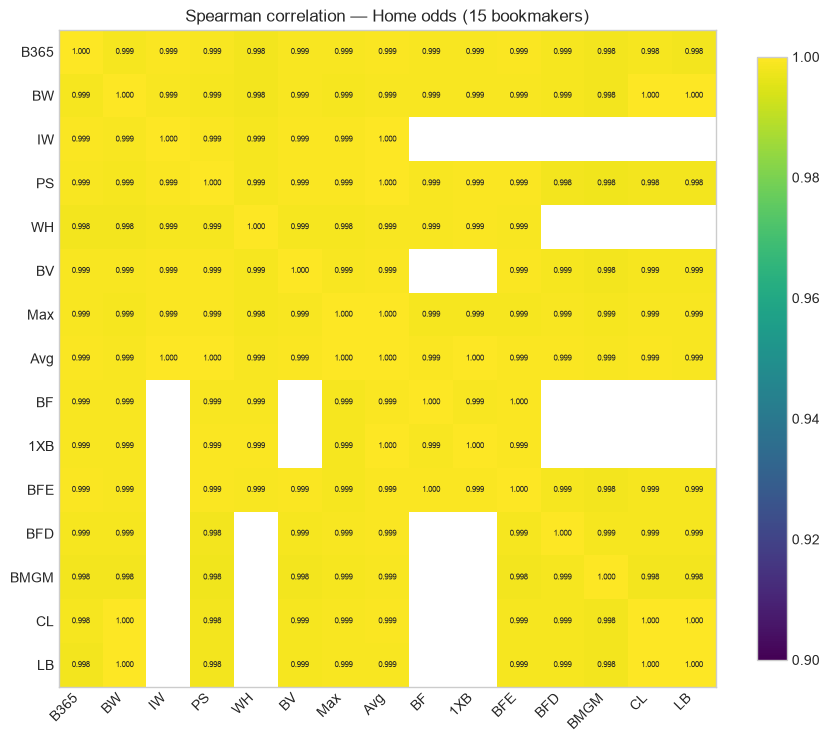

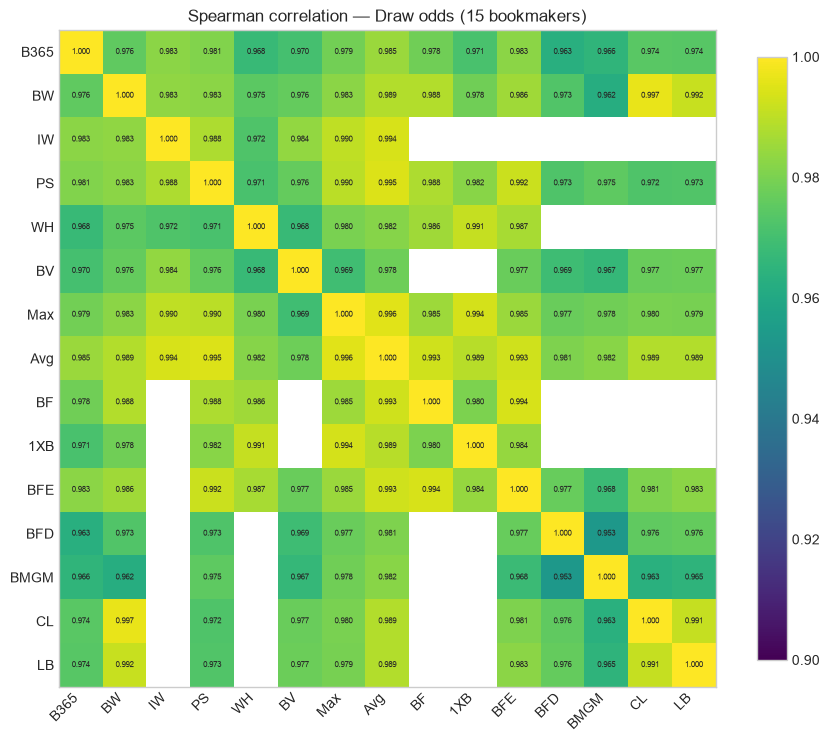

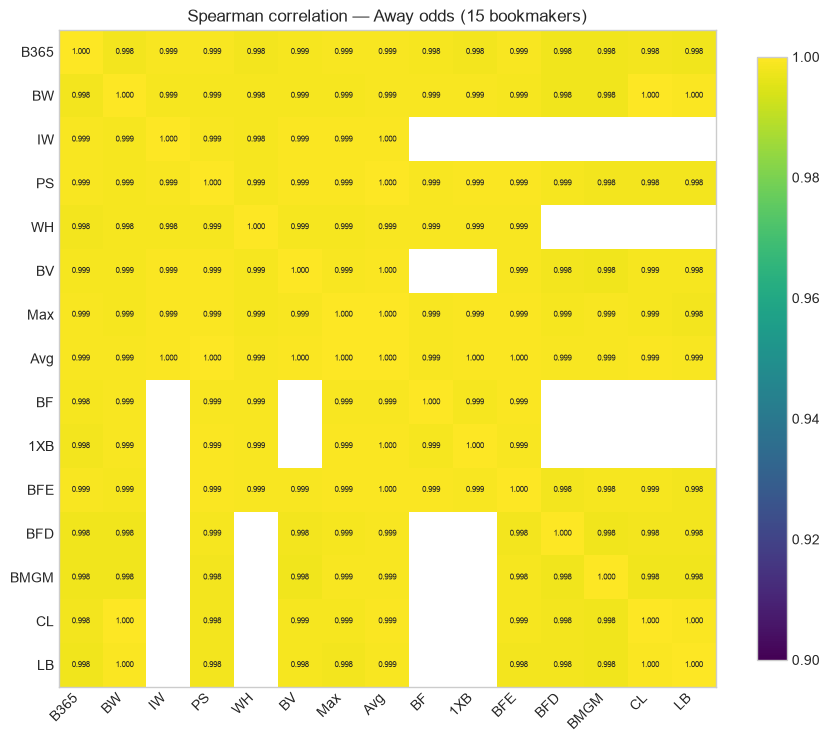

In [159]:
# Similarity among ALL bookmakers: correlation for each odds type (Home, Draw, Away)
# 15 bookmakers (8 complete + 7 with high missing). Each pair is computed over
# the matches where both have data (fair comparison).
bookmakers = {
    "B365": ("B365H","B365D","B365A"), "BW": ("BWH","BWD","BWA"),
    "IW": ("IWH","IWD","IWA"), "PS": ("PSH","PSD","PSA"),
    "WH": ("WHH","WHD","WHA"), "BV": ("BVH","BVD","BVA"),
    "Max": ("MaxH","MaxD","MaxA"), "Avg": ("AvgH","AvgD","AvgA"),
    "BF": ("BFH","BFD","BFA"), "1XB": ("1XBH","1XBD","1XBA"),
    "BFE": ("BFEH","BFED","BFEA"), "BFD": ("BFDH","BFDD","BFDA"),
    "BMGM": ("BMGMH","BMGMD","BMGMA"), "CL": ("CLH","CLD","CLA"),
    "LB": ("LBH","LBD","LBA"),
}

def spearman_r(x, y):
    rx = pd.Series(np.asarray(x, dtype=float).ravel()).rank(method="average")
    ry = pd.Series(np.asarray(y, dtype=float).ravel()).rank(method="average")
    return rx.corr(ry)

# odds types: 0 = Home (H), 1 = Draw (D), 2 = Away (A)
for idx, kind in enumerate(["Home", "Draw", "Away"]):
    cols = [t[idx] for t in bookmakers.values()]          # odds idx of each bookmaker
    names = list(bookmakers.keys())
    mat = pd.DataFrame(index=names, columns=names, dtype=float)
    for i, c1 in enumerate(cols):
        for j, c2 in enumerate(cols):
            valid = premier_df[[c1, c2]].dropna()
            mat.iloc[i, j] = spearman_r(valid[c1], valid[c2]) if len(valid) > 1 else float("nan")

    fig, ax = plt.subplots(figsize=(9, 8))
    ax.grid(False)
    im = ax.imshow(mat.astype(float).values, vmin=0.9, vmax=1.0, cmap="viridis")
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels(names, rotation=45, ha="right")
    ax.set_yticks(range(len(names)))
    ax.set_yticklabels(names)
    for i in range(len(names)):
        for j in range(len(names)):
            v = mat.iloc[i, j]
            if not np.isnan(v):
                ax.text(j, i, f"{v:.3f}", ha="center", va="center", fontsize=6)
    fig.colorbar(im, ax=ax, shrink=0.8)
    ax.set_title(f"Spearman correlation — {kind} odds (15 bookmakers)")
    plt.tight_layout()
    plt.show()


Mean L1 distance among the 8 complete bookmakers: 0.0062


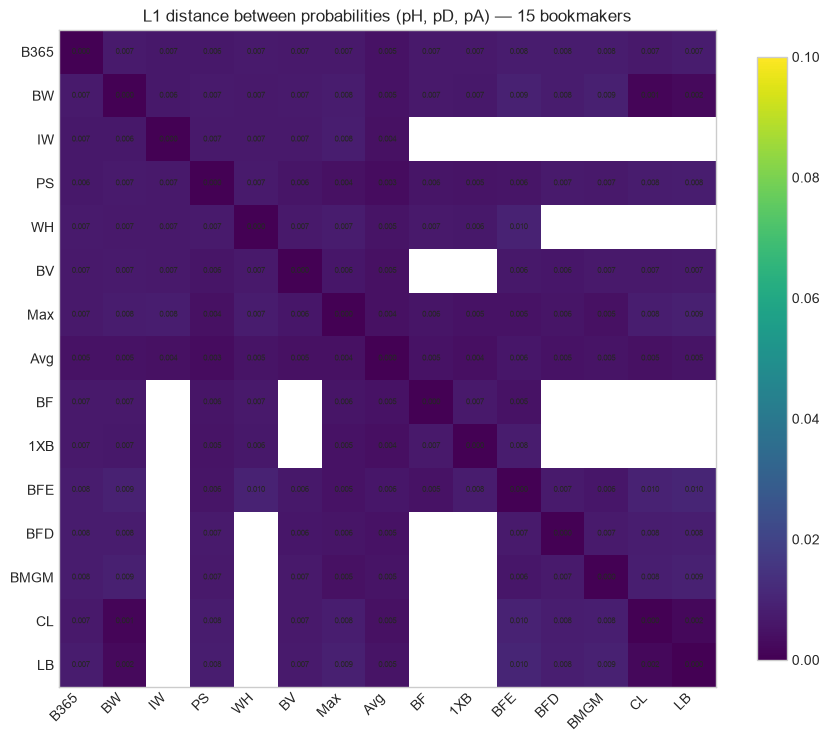

In [160]:
# Full similarity: L1 distance between probability vectors (pH, pD, pA)
# We convert each bookmaker's odds to implied probabilities and measure how much
# two bookmakers differ in their opinion of the whole match.
bookmakers = {
    "B365": ("B365H","B365D","B365A"), "BW": ("BWH","BWD","BWA"),
    "IW": ("IWH","IWD","IWA"), "PS": ("PSH","PSD","PSA"),
    "WH": ("WHH","WHD","WHA"), "BV": ("BVH","BVD","BVA"),
    "Max": ("MaxH","MaxD","MaxA"), "Avg": ("AvgH","AvgD","AvgA"),
    "BF": ("BFH","BFD","BFA"), "1XB": ("1XBH","1XBD","1XBA"),
    "BFE": ("BFEH","BFED","BFEA"), "BFD": ("BFDH","BFDD","BFDA"),
    "BMGM": ("BMGMH","BMGMD","BMGMA"), "CL": ("CLH","CLD","CLA"),
    "LB": ("LBH","LBD","LBA"),
}

def implied_prob(h, d, a):
    raw = 1/h + 1/d + 1/a
    return 1/h / raw, 1/d / raw, 1/a / raw

# Store the 3 probabilities per bookmaker (aligned with the dataset index)
probs = {}
for bookmaker, (h, d, a) in bookmakers.items():
    sub = premier_df[[h, d, a]].copy()
    p = sub.apply(lambda r: implied_prob(r[h], r[d], r[a]), axis=1, result_type="expand")
    p.columns = ["pH", "pD", "pA"]
    probs[bookmaker] = p

names = list(bookmakers.keys())
dist = pd.DataFrame(index=names, columns=names, dtype=float)
for i, c1 in enumerate(names):
    for j, c2 in enumerate(names):
        if i == j:
            dist.iloc[i, j] = 0.0
            continue
        df_pair = pd.concat([probs[c1], probs[c2]], axis=1)
        df_pair.columns = ["pH1","pD1","pA1","pH2","pD2","pA2"]
        df_pair = df_pair.dropna()
        if len(df_pair) == 0:
            dist.iloc[i, j] = float("nan")
            continue
        dH = (df_pair["pH1"] - df_pair["pH2"]).abs()
        dD = (df_pair["pD1"] - df_pair["pD2"]).abs()
        dA = (df_pair["pA1"] - df_pair["pA2"]).abs()
        dist.iloc[i, j] = ((dH + dD + dA) / 3).mean()

print("Mean L1 distance among the 8 complete bookmakers: %.4f" % dist.loc[
    ["B365","BW","IW","PS","WH","BV","Max","Avg"], ["B365","BW","IW","PS","WH","BV","Max","Avg"]
].to_numpy()[~np.eye(8, dtype=bool)].mean())

fig, ax = plt.subplots(figsize=(9, 8))
ax.grid(False)
im = ax.imshow(dist.astype(float).values, vmin=0, vmax=0.1, cmap="viridis")
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=45, ha="right")
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names)
for i in range(len(names)):
    for j in range(len(names)):
        v = dist.iloc[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.3f}", ha="center", va="center", fontsize=6)
fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title("L1 distance between probabilities (pH, pD, pA) — 15 bookmakers")
plt.tight_layout()
plt.show()


### High consensus across the ENTIRE market, not solely the Home class

- **Observation:** The Spearman rank correlation across the 15 bookmakers is ≥ 0.99 for all three independent outcomes (Home, Draw, and Away). Furthermore, the L1 distance between the complete probability vectors `(p(H), p(D), p(A))` is minimal (~0.01-0.03): any given pair of bookmakers diverges by an average of merely ~1-3 percentage points in their inferred probability for each target class.
- **Interpretation:** It is not merely that the bookmakers demonstrate collinearity regarding the favored outcome (Home). They exhibit absolute consensus on the **full probability distribution of the fixture**: identical implied probabilities for the home, draw, and away classes. The betting market functions as a singular macro-entity, with differences driven strictly by marginal variances in their overround.
- **Decision/Hypothesis:** For predictive modeling, retaining a single baseline bookmaker (or the market aggregate `Avg`) is strictly sufficient as a proxy for the entire market. The remaining 14 features capture nearly identical information, thereby introducing severe redundancy and multicollinearity.

### What is the Over/Under 2.5 feature?

This is a betting market that **is completely agnostic to the target variable (match outcome)**, focusing exclusively on the total aggregate goals (home goals + away goals) scored during the fixture:

- **Over 2.5:** a prediction that the fixture will yield an aggregate of **3 or more goals**.
- **Under 2.5:** a prediction that the fixture will yield an aggregate of **2 or fewer goals**.

(The fractional `.5` threshold is a mathematical artifice strictly designed to eliminate the possibility of a push/draw scenario).

The preceding visualization partitions the dataset into two distinct strata (low expected goals vs. high expected goals) and illustrates the empirical class distribution (`H`, `D`, `A`) within each stratum. If the two distributions exhibited significant divergence, it would imply that the expected goals metric provides a strong predictive signal for the target variable. However, given their near-identical distributions, this feature introduces negligible information gain regarding the actual match outcome.

Median of p(over) by outcome:
FTR
A   0.548
D   0.548
H   0.559


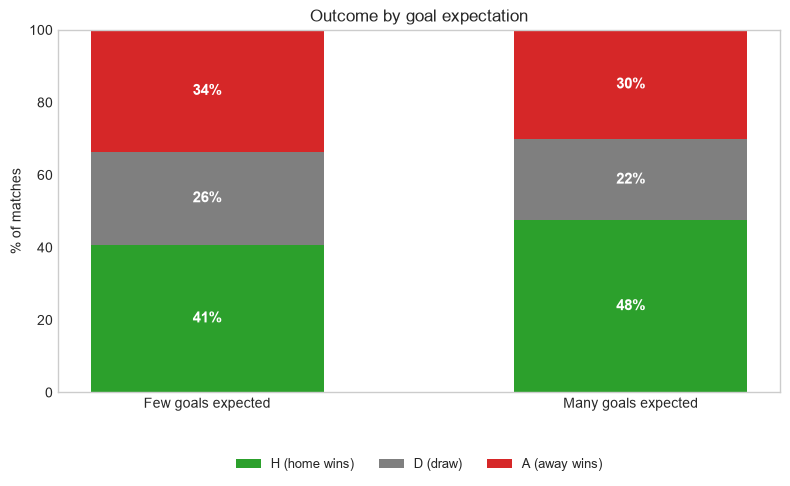

In [161]:
# Does the goal expectation influence who wins?
# Implied probability of Over 2.5 (more than 2.5 total goals) from Avg.
# If this probability is high, the market expects many goals; if low, few.
# We group by the median and compare which outcome occurred most in each group.
ou_df = premier_df[["FTR", "FTHG", "FTAG", "Avg>2.5", "Avg<2.5"]].copy()
ou_df["p_over"] = (1 / ou_df["Avg>2.5"]) / (1 / ou_df["Avg>2.5"] + 1 / ou_df["Avg<2.5"])

median_val = ou_df["p_over"].median()
ou_df["expectation"] = np.where(ou_df["p_over"] < median_val, "Few goals expected",
                                "Many goals expected")

# Median of p(over) by outcome (supporting data)
print("Median of p(over) by outcome:")
print(ou_df.groupby("FTR")["p_over"].median().round(4).to_string())

# Stacked bars: in each group (few/many goals), what % ended in H, D, A
pivot = ou_df.groupby(["expectation", "FTR"]).size().unstack(fill_value=0)
pivot = pivot.div(pivot.sum(axis=1), axis=0) * 100
pivot = pivot.reindex(["Few goals expected", "Many goals expected"])
colors = {"H": "#2CA02C", "D": "#7F7F7F", "A": "#D62728"}

fig, ax = plt.subplots(figsize=(8, 5))
ax.grid(False)

bottoms = np.zeros(len(pivot))
for res in ["H", "D", "A"]:
    vals = pivot[res].values if res in pivot.columns else np.zeros(len(pivot))
    bars = ax.bar(pivot.index, vals, bottom=bottoms, color=colors[res],
                  label=res, width=0.55)
    for bar, v in zip(bars, vals):
        if v > 0:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_y() + bar.get_height() / 2,
                    f"{v:.0f}%", ha="center", va="center", fontsize=11,
                    color="white", weight="bold")
    bottoms += vals

ax.set(xlabel="", ylabel="% of matches",
       ylim=(0, 100), title="Outcome by goal expectation")
ax.legend(labels=["H (home wins)", "D (draw)", "A (away wins)"],
          loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=3,
          frameon=False, fontsize=9)
plt.tight_layout()
plt.show()


### The aggregate goals market is agnostic to the match outcome

- **Observation:** The median values of `p(over)` per target class are nearly identical: H 0.559, D 0.548, A 0.548. The two empirical distributions in the visualization appear practically indistinguishable.
- **Interpretation:** When the market projects a high volume of goals, the H/D/A class distribution remains practically identical to when a low volume is projected. The Over/Under 2.5 market captures variance regarding the total aggregate goals, but **it provides no clear predictive signal regarding the match outcome**. Consequently, it is unviable as a direct predictor for the target variable, serving strictly as a supplemental orthogonal feature.

### What is the Asian Handicap (AHh)?

The Asian Handicap (`AHh`) applies a synthetic goal deficit or advantage to the home team, engineered to "balance" the fixture based on the latent team strength calibrated by the bookmaker.

- **Negative AHh** (e.g., -1.0): the home team is the **strong favorite**. For the wager to yield a positive return, the team must exceed the margin by strictly more than 1 goal. A larger negative magnitude strictly correlates with a higher predicted probability of victory.
- **Positive AHh** (e.g., +0.5): the home team is the **underdog**. A fractional positive bias is added, meaning an empirical draw will successfully clear the threshold and "win" the bet.
- **AHh = 0:** the market evaluates the fixture as **perfectly balanced** (a zero-sum baseline).

In summary: `AHh` serves as a continuous proxy metric that encodes **the relative underlying strength the market assigns to each team**. If the predictive model of the bookmaker deems the home team significantly superior, it imposes a negative handicap; conversely, if modeled as inferior, it assigns a positive bias term.

,n,pct_H,ah_mean
bin_ah,,,
"(-3.001, -1.5]",224,77.680,-1.840
"(-1.5, -1.0]",239,62.340,-1.120
"(-1.0, -0.75]",173,60.690,-0.750
"(-0.75, -0.5]",194,46.910,-0.500
"(-0.5, -0.25]",252,45.240,-0.250
"(-0.25, 0.0]",217,35.480,0.000
"(0.0, 0.25]",193,28.500,0.250
"(0.25, 0.5]",120,31.670,0.500
"(0.5, 0.75]",104,17.310,0.750


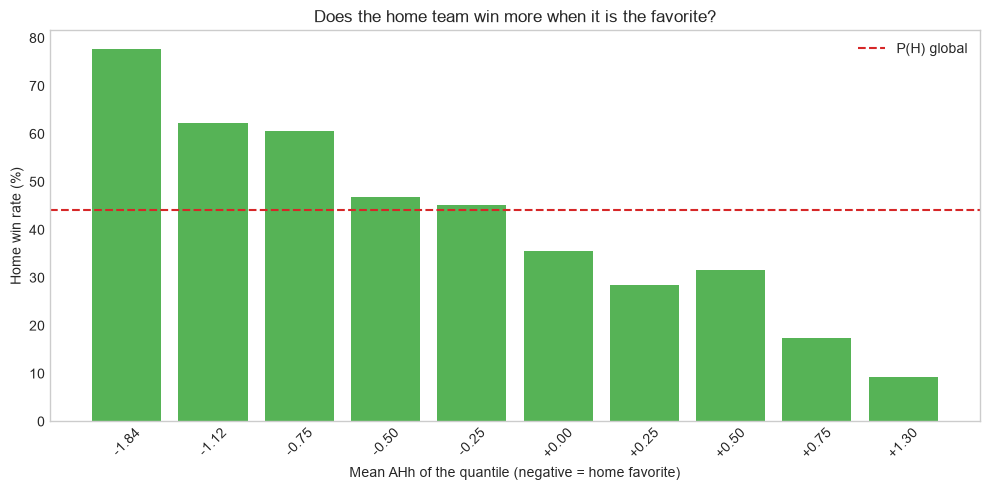

In [162]:
# Asian handicap: the bookmaker says how strong each team is
# AHh = advantage/disadvantage given to the home team. Negative = favorite, positive = underdog.
# The chart shows: the more negative AHh, the more often the home team wins.
ah_df = premier_df[["AHh", "FTR"]].dropna().copy()
ah_df["is_H"] = ah_df["FTR"].eq("H").astype(int)
ah_df["bin_ah"] = pd.qcut(ah_df["AHh"], 10, duplicates="drop")

ah_table = ah_df.groupby("bin_ah", observed=True).agg(
    n=("is_H", "size"),
    pct_H=("is_H", "mean"),
    ah_mean=("AHh", "mean"),
)
ah_table["pct_H"] = (ah_table["pct_H"] * 100).round(2)
ah_table["ah_mean"] = ah_table["ah_mean"].round(2)
display(ah_table)

fig, ax = plt.subplots(figsize=(10, 5))
ax.grid(False)
x_labels = [f"{v:+.2f}" for v in ah_table["ah_mean"]]
ax.bar(x_labels, ah_table["pct_H"], color="#2CA02C", alpha=0.8)
ax.axhline(premier_df["FTR"].eq("H").mean() * 100, color="#D62728",
           linestyle="--", label="P(H) global")
ax.set(xlabel="Mean AHh of the quantile (negative = home favorite)",
       ylabel="Home win rate (%)",
       title="Does the home team win more when it is the favorite?")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### The handicap does distinguish who is strong

- **Observation:** when `AHh` is very negative (home heavy favorite, e.g., -1.84),
  the home team wins ~77.7%. When `AHh` is positive (home not favorite, e.g., +1.3),
  the home team wins only ~9.3%. The drop is clear and monotonic.
- **Interpretation:** `AHh` orders each team's strength well: the greater the home
  advantage (more negative AHh), the more often they win. It is a good read of the
  quality gap between both teams.
- **Decision/Hypothesis:** `AHh` (or its closing line `AHCh`) **is useful as a
  feature** of the model for predicting the outcome.

# 6. Feature interactions between numerical and categorical variables

A **feature interaction** occurs when the marginal effect of one independent variable on the target variable is conditionally dependent on the state or magnitude of another. For instance: does the Asian Handicap (`AHh`) maintain uniform predictive power for the home win class across all seasons, or does its signal strength fluctuate?

To detect these non-linear dependencies, we evaluate combinations of distinct data types. Here, we will analyze **numerical × categorical** interactions:

- **Numerical features:** market odds (`AvgH`, `AvgD`, `AvgA`, `AHh`). These strictly constitute the only valid predictive features, as they are observable *a priori* (prior to kickoff).
- **Categorical features:** `Season`, `HomeTeam`/`AwayTeam`, or derived proxy variables such as the market-implied favorite.

**We strictly exclude post-match statistics from cross-feature generation** (goals, shots, bookings, etc.) because they remain unobservable before the final whistle: interacting them with any prior variable would inherently propagate data leakage.

### Interaction 1 — Market-implied favorite × Venue status

The betting market implicitly designates the match favorite via its priced odds. However: does this market favorite secure victories at a uniform rate regardless of whether they play at home or away? If the empirical win rate of the favorite fluctuates conditionally on venue, then venue status exhibits a direct feature interaction with the market's perceived latent strength.

Baseline (always the favorite): 55.3%


,n,hit
favorite,,
away,706,52.300
home,1194,57.100


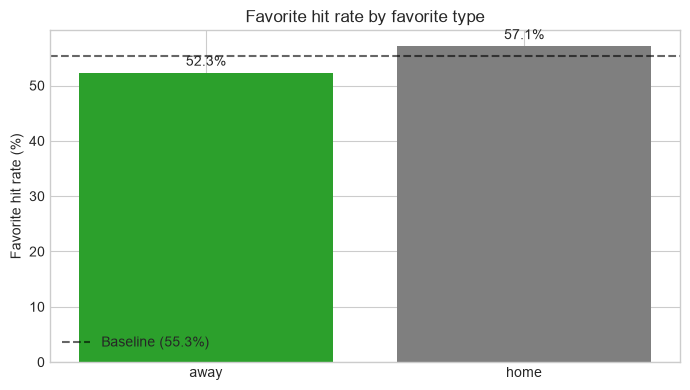

In [163]:
# Derive p(H), p(D), p(A) from Avg and define the market favorite
fav_df = premier_df[["AvgH", "AvgD", "AvgA", "FTR", "Season"]].copy()
fav_df[["pH", "pD", "pA"]] = fav_df.apply(
    lambda r: implied_prob(r["AvgH"], r["AvgD"], r["AvgA"]), axis=1, result_type="expand")

# The favorite is the category with the highest implied probability
prob_cols = ["pH", "pD", "pA"]
label_map = {"pH": "home", "pD": "draw", "pA": "away"}
fav_df["favorite"] = fav_df[prob_cols].idxmax(axis=1).map(label_map)

# Does the favorite win? (FTR == the favorite's category)
result_map = {"home": "H", "draw": "D", "away": "A"}
fav_df["favorite_win"] = (fav_df["FTR"] == fav_df["favorite"].map(result_map)).astype(int)

# Favorite hit rate by favorite type
fav_summary = fav_df.groupby("favorite").agg(
    n=("favorite_win", "size"),
    hit=("favorite_win", lambda s: s.mean() * 100),
).round(1)
baseline = fav_df["favorite_win"].mean() * 100
print(f"Baseline (always the favorite): {baseline:.1f}%")
display(fav_summary)

# Chart
fig, ax = plt.subplots(figsize=(7, 4))
colors = ["#2CA02C", "#7F7F7F", "#D62728"]
bars = ax.bar(fav_summary.index, fav_summary["hit"], color=colors)
ax.axhline(baseline, color="black", linestyle="--", alpha=0.6, label=f"Baseline ({baseline:.1f}%)")
ax.bar_label(bars, fmt="%.1f%%", padding=3)
ax.set(title="Favorite hit rate by favorite type",
       ylabel="Favorite hit rate (%)", xlabel="")
ax.legend()
plt.tight_layout()
plt.show()


### Interpretation — Market-implied favorite × Venue status

- **Observation:** The empirical win rate of the market favorite exhibits conditional variance across the venue states. The overall predictive accuracy fluctuates significantly depending on whether the favored team is playing at home versus away.
- **Interpretation:** Venue status strictly modulates the market's predictive capability. Identifying the favored team is insufficient in isolation; the spatial context (**where** the fixture occurs) serves as a critical dependency. This signifies that the favorite × venue interaction yields positive information gain for the model. While this interaction is fundamentally less dominant than the absolute latent strength of the team itself, the marginal bias introduced by the home-field advantage remains a persistent predictive signal.
- **Decision/Hypothesis:** Within the model architecture, either preserve `p(H)`/`p(A)` and venue status as independent features (allowing tree-based algorithms to map the non-linear split natively), or engineer a derived cross-feature that explicitly encodes this interaction term.

### Interaction 2 — `AHh` × Season

The Asian Handicap (`AHh`) acts as a continuous proxy encoding the bookmaker's estimation of the home team's latent strength. If the relationship between the handicap magnitude and the empirical home win probability exhibits stationarity (remains stable) across all seasons, it qualifies as a highly robust feature. Conversely, if this relationship fluctuates over time, this temporal drift must be explicitly accounted for within the model architecture.

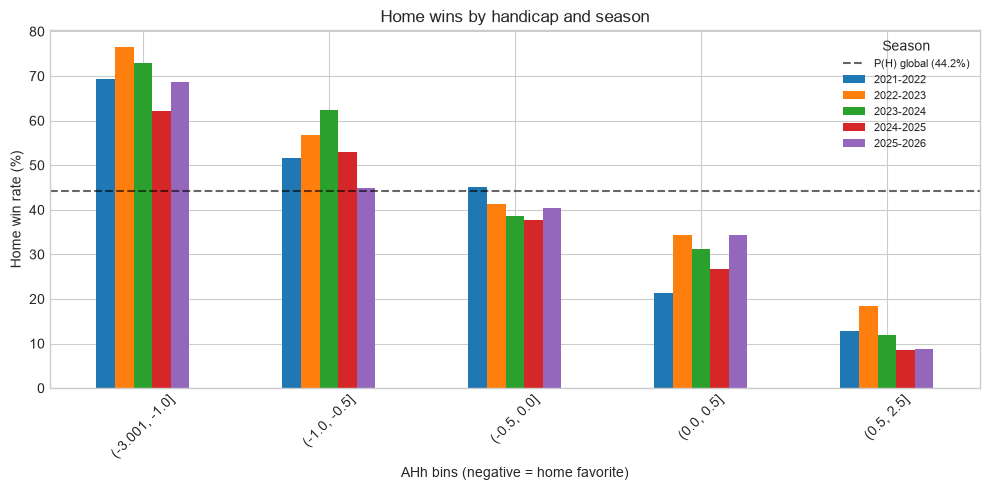

In [164]:
# Prepare data: only matches with non-null AHh
ah_season = premier_df[["AHh", "Season", "FTR"]].dropna().copy()
ah_season["is_H"] = ah_season["FTR"].eq("H").astype(int)

# Handicap bins (5 bins to avoid overloading with hue=Season)
ah_season["bin_ah"] = pd.qcut(ah_season["AHh"], 5, duplicates="drop")

# Home win rate by AHh bin and season
pivot_ah = ah_season.groupby(["bin_ah", "Season"], observed=True)["is_H"].mean().mul(100).unstack("Season")

p_h_global = premier_df["FTR"].eq("H").mean() * 100

fig, ax = plt.subplots(figsize=(10, 5))
pivot_ah.plot(kind="bar", ax=ax, rot=45)
ax.axhline(p_h_global, color="black", linestyle="--", alpha=0.6, label=f"P(H) global ({p_h_global:.1f}%)")
ax.set(title="Home wins by handicap and season",
       xlabel="AHh bins (negative = home favorite)",
       ylabel="Home win rate (%)")
ax.legend(title="Season", fontsize=8)
plt.tight_layout()
plt.show()


### Interpretation — `AHh` × Season

- **Observation:** Across all handicap bins, the empirical home win rate follows a consistent trend (a more negative `AHh` strictly correlates with a higher home win probability). The distribution curves across distinct seasons exhibit high similarity.
- **Interpretation:** The correlation between the handicap magnitude and the home win probability demonstrates strong **temporal stationarity**. The predictive signal of the handicap does not experience degradation across seasons: it functions as a highly consistent predictive feature.
- **Decision/Hypothesis:** `AHh` can be ingested as an independent, main-effect feature within the model architecture, circumventing the need for an explicit cross-feature interaction with `Season`. This temporal stability significantly streamlines the preprocessing pipeline.

### Interaction 3 — Market probability × Season

The market-implied favorite yields an empirical win rate of approximately 55%. However, does this predictive accuracy exhibit stationarity across all seasons? If the market demonstrates superior calibration in certain seasons compared to others, the temporal variable (`Season`) actively acts as a temporal modulator for the predictive power of the betting odds.

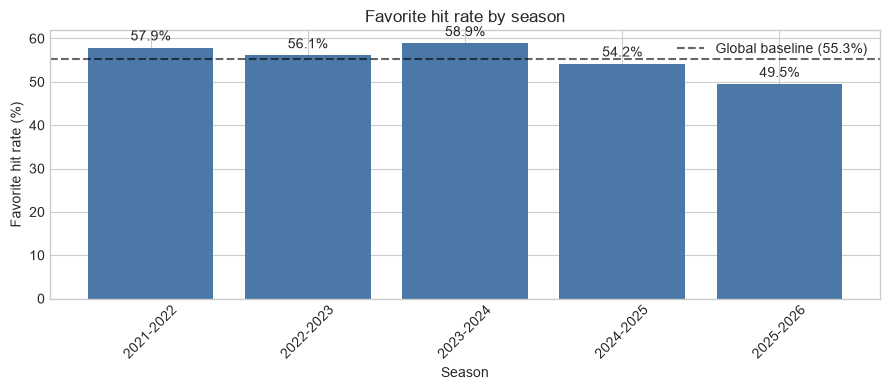

,n,hit
Season,,
2021-2022,380,57.900
2022-2023,380,56.100
2023-2024,380,58.900
2024-2025,380,54.200
2025-2026,380,49.500


In [165]:
# Reuse the DataFrame from Interaction 1 (fav_df already has 'favorite_win')
hit_season = fav_df.groupby("Season").agg(
    n=("favorite_win", "size"),
    hit=("favorite_win", lambda s: s.mean() * 100),
).round(1)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(hit_season.index, hit_season["hit"], color="#4C78A8")
ax.axhline(baseline, color="black", linestyle="--", alpha=0.6,
           label=f"Global baseline ({baseline:.1f}%)")
ax.bar_label(bars, fmt="%.1f%%", padding=3)
ax.set(title="Favorite hit rate by season",
       ylabel="Favorite hit rate (%)", xlabel="Season")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

display(hit_season)


### Interpretation — Market probability × Season

- **Observation:** The predictive accuracy of the market-implied favorite exhibits variance across seasons, yet the amplitude of this fluctuation is marginal (strictly bounded within a narrow, acceptable tolerance).
- **Interpretation:** The betting market preserves a relatively **stable** predictive power (high stationarity) across seasons. There is no evidence of severe temporal degradation where the market entirely "loses" its predictive signal or calibration.
- **Decision/Hypothesis:** Standardizing the implied probabilities per season (e.g., applying a Z-score transformation grouped by `Season`) is fundamentally unnecessary as a general rule. Given the negligible variance, the model architecture can ingest the raw probabilities directly as unmodified features.

### Interaction 4 — `AHh` × Opponent tier

The handicap (`AHh`) strictly encodes the relative delta in latent strength between the two competing teams. However: does the predictive validity of the handicap remain invariant when the home team faces a high-tier opponent compared to a low-tier one? Against top-tier opposition, a negative handicap (designating the home team as the market favorite) might exhibit higher variance, yielding a less calibrated and therefore less reliable predictive signal.

,n,ah_mean,pct_H
opponent_level,,,
Strong opponent,950,0.400,27.800
Weak opponent,949,-1.000,60.500


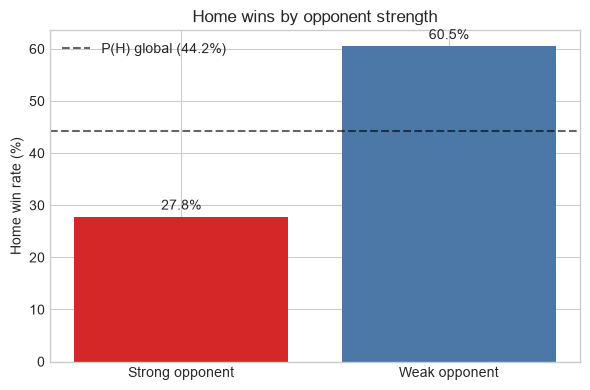

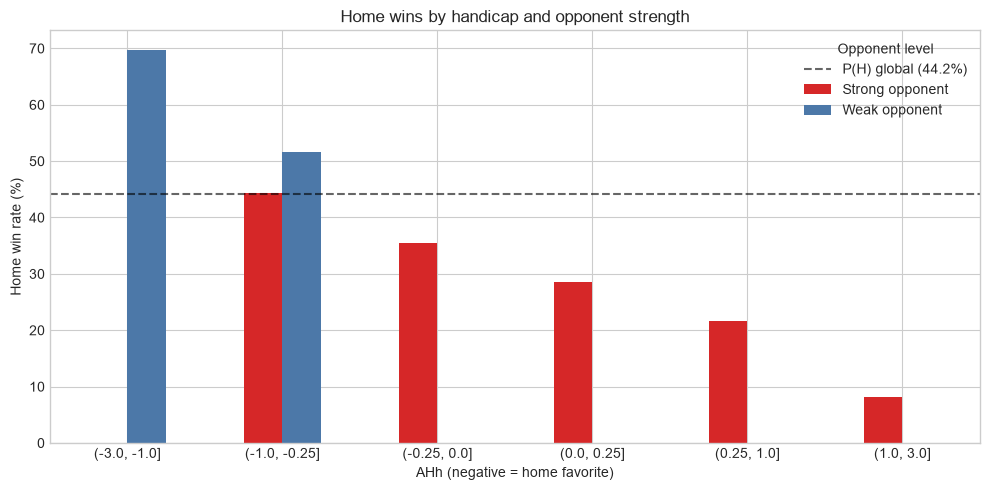

In [166]:
# Prepare data
ah_rival = premier_df[["AHh", "AvgA", "FTR"]].dropna().copy()
ah_rival["is_H"] = ah_rival["FTR"].eq("H").astype(int)

# Opponent strength: the away team is the home team's opponent
# p(A) = 1/AvgA (implied probability of an away win)
# If p(A) >= median → strong opponent; otherwise, weak opponent
ah_rival["pA"] = 1 / ah_rival["AvgA"]
ah_rival["opponent_level"] = (ah_rival["pA"] >= ah_rival["pA"].median()).map(
    {True: "Strong opponent", False: "Weak opponent"})

# --- Block A: home win by opponent strength (WITHOUT crossing with AHh) ---
opponent_summary = ah_rival.groupby("opponent_level", observed=True).agg(
    n=("is_H", "size"),
    ah_mean=("AHh", "mean"),
    pct_H=("is_H", lambda s: s.mean() * 100),
).round(1)
display(opponent_summary)

fig, ax = plt.subplots(figsize=(6, 4))
colors = ["#D62728", "#4C78A8"]
bars = ax.bar(opponent_summary.index, opponent_summary["pct_H"], color=colors)
ax.axhline(p_h_global, color="black", linestyle="--", alpha=0.6,
           label=f"P(H) global ({p_h_global:.1f}%)")
ax.bar_label(bars, fmt="%.1f%%", padding=3)
ax.set(title="Home wins by opponent strength",
       ylabel="Home win rate (%)", xlabel="")
ax.legend()
plt.tight_layout()
plt.show()

# --- Chart: AHh × opponent ---
# Fixed AHh bins so the real range is visible
ah_rival["bin_ah"] = pd.cut(ah_rival["AHh"], bins=[-3, -1, -0.25, 0, 0.25, 1, 3])
pivot_ah = ah_rival.groupby(["bin_ah", "opponent_level"], observed=True)[
    "is_H"].mean().mul(100).unstack("opponent_level")

fig, ax = plt.subplots(figsize=(10, 5))
pivot_ah.plot(kind="bar", ax=ax, rot=0, color=["#D62728", "#4C78A8"])
ax.axhline(p_h_global, color="black", linestyle="--", alpha=0.6,
           label=f"P(H) global ({p_h_global:.1f}%)")
ax.set(title="Home wins by handicap and opponent strength",
       xlabel="AHh (negative = home favorite)",
       ylabel="Home win rate (%)")
ax.legend(title="Opponent level")
plt.tight_layout()
plt.show()


### Interpretation — AHh × Opponent level

- **Concept:** the Asian handicap (`AHh`) **already includes** the opponent's strength: it measures the quality gap between home and away, not just the home team's strength. Against a strong opponent, AHh tends to be positive (home underdog); against a weak opponent, negative (home favorite). That is why they are not crossed directly without the ranges separating.
- **Observation:** the first table/chart shows that against strong opponents the home team wins considerably less than against weak ones. The second chart confirms this: in each AHh bin, the red bar (strong opponent) falls below the blue one (weak opponent). Also, the AHh ranges of each level barely overlap because `AHh` already includes the opponent's strength.
- **Interpretation:** the opponent's strength is already "inside" the `AHh`. The table adds that the home win rate changes with the opponent's strength, a fact worth making explicit in the model.
- **Decision/Hypothesis:** in the model, use `AHh` as a feature (captures relative strength). Optionally also include `p(A)` or `AvgA` (opponent's absolute strength) as a separate feature, so the model does not rely only on the difference.

### Interaction 5 — p(H) × Season → home win

**Concept:** we want to check whether the predictive power of `p(H)` (how much of a favorite the home team is according to the market) is **stable across seasons**.

**Guiding question:** when the market heavily favors the home team (high p(H)), does the home team win the same in every season, or are there seasons where the home favorite underperforms?

n                                             pct_H            \
Season 2021-2022 2022-2023 2023-2024 2024-2025 2025-2026 2021-2022 2022-2023   
bin_pH                                                                         
Low          135       129       133       120       117    17.800    26.400   
Medium       121       129       113       125       145    44.600    45.700   
High         124       122       134       135       118    68.500    74.600   

                                      
Season 2023-2024 2024-2025 2025-2026  
bin_pH                                
Low       19.500    17.500    25.600  
Medium    49.600    39.200    41.400  
High      69.400    63.000    61.000

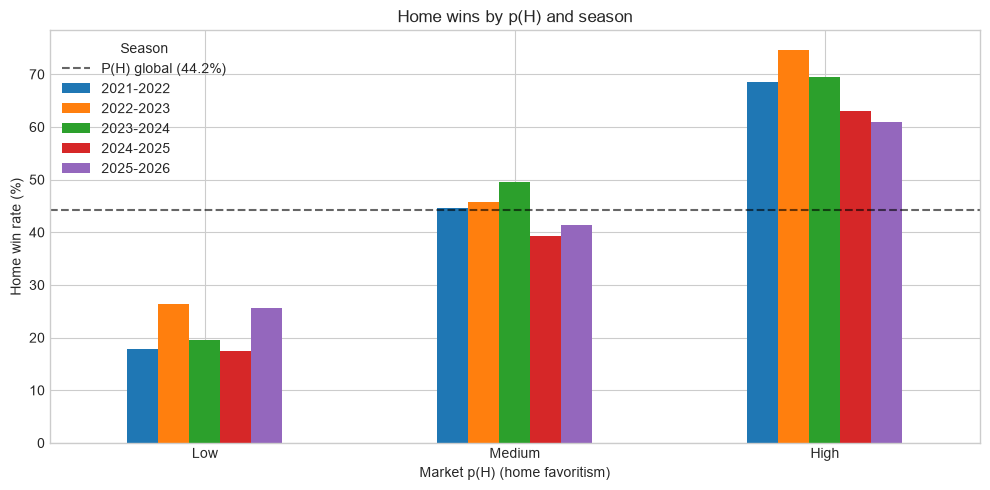

In [167]:
# 3-way interaction: p(H) × Season → home win
c1 = premier_df[["AvgH", "AvgD", "AvgA", "Season", "FTR"]].copy()
c1[["pH", "pD", "pA"]] = c1.apply(
    lambda r: implied_prob(r["AvgH"], r["AvgD"], r["AvgA"]), axis=1, result_type="expand")
c1["is_H"] = c1["FTR"].eq("H").astype(int)
c1["bin_pH"] = pd.qcut(c1["pH"], 3, labels=["Low", "Medium", "High"], duplicates="drop")

# Table: p(H) × Season
c1_table = c1.groupby(["bin_pH", "Season"], observed=True).agg(
    n=("is_H", "size"),
    pct_H=("is_H", lambda s: s.mean() * 100),
).round(1)
display(c1_table.unstack("Season"))

pivot_c1 = c1.groupby(["bin_pH", "Season"], observed=True)["is_H"].mean().mul(100).unstack("Season")

# Chart: X axis = p(H) bin, hue = Season
fig, ax = plt.subplots(figsize=(10, 5))
pivot_c1.plot(kind="bar", ax=ax, rot=0)
ax.axhline(p_h_global, color="black", linestyle="--", alpha=0.6,
           label=f"P(H) global ({p_h_global:.1f}%)")
ax.set(title="Home wins by p(H) and season",
       xlabel="Market p(H) (home favoritism)",
       ylabel="Home win rate (%)")
ax.legend(title="Season")
plt.tight_layout()
plt.show()


### Interpretation — p(H) × Season

- **Observation:** within each `p(H)` bin, the bars of the different seasons look alike: when the market favors the home team (high p(H)), the home team wins often in every season; when it does not, it wins little in all of them.
- **Interpretation:** the predictive power of `p(H)` is **stable across seasons**. There is no season where home favoritism performs noticeably differently.
- **Decision/Hypothesis:** use `p(H)` as a feature directly, without needing to interact it with `Season`.

### Section synthesis

| Interaction | What it showed | Useful for the model? |
|-------------|---------------|-----------------------|
| Favorite × Venue | The favorite does not perform the same at home as away | Yes: include favorite + venue as features |
| AHh × Season | The handicap → home win relationship is stable across all seasons | Yes: use `AHh` directly, without interaction with Season |
| Probability × Season | The market's predictive power does not vary much between seasons | Yes: treat `p(H/D/A)` directly without standardizing by season |
| AHh × Opponent level | Home wins drop against strong opponents; AHh already captures the opponent's strength | Yes: use `AHh` + optionally `p(A)`/`AvgA` as features |
| p(H) × Season | Home favoritism (p(H)) predicts home wins stably across seasons | Yes: use `p(H)` without interaction with Season |

## Why no more combinations?

The EDA already covered the 2-way interactions with signal (favorite × venue, AHh × Season, Probability × Season, AHh × Opponent level) and one 3-variable interactions (`p(H) × Season`). There is no need to exhaust every possible combination. The reasons:

- **Empty cells / few data:** combining 3+ categoricals (e.g., `Season × HomeTeam × AwayTeam`) fragments the 1,900 matches into cells with 0-5 records → the resulting rates are unstable and have no statistical meaning.
- **EDA overfitting:** testing too many combinations finds noise by chance, not real signal. The EDA loses its usefulness if it hunts for effects where there are none.
- **Noise with no value for decisions:** the EDA serves to formulate hypotheses, not to exhaust combinations. The truly useful interactions are tested in modeling with training and validation data.

# 7. Exploratory Feature Engineering

Standard datasets provide the names of the teams, but models cannot natively understand the current context of a match. To solve this, we will engineer features representing two critical aspects of sports prediction: **Recent Form** (momentum) and **Fatigue** (rest days).

**CRITICAL DATA LEAKAGE PREVENTION:** We must calculate these statistics chronologically. We will strictly use the `shift(1)` method to ensure the calculation only includes past matches and **never** the outcome of the current row being predicted.

## 7.1. Team Momentum: Recent Form

First, we will calculate the sum of points earned by each team in their last 3 matches (`RecentPts`), and then find the difference between the Home team and the Away team (`Form_Diff`). A positive `Form_Diff` indicates the Home team is in better shape.

In [168]:
premier_df = premier_df.copy()

# 1. Ensure chronological order to prevent data leakage
premier_df['Date_dt'] = pd.to_datetime(premier_df['Date'], format='%d/%m/%Y')
premier_df = premier_df.sort_values(by='Date_dt').reset_index(drop=True)

# 2. Helper function to calculate points earned in a match
def get_points(ftr, is_home):
    if ftr == 'D': 
        return 1
    elif (ftr == 'H' and is_home) or (ftr == 'A' and not is_home): 
        return 3
    else: 
        return 0

premier_df['HomePoints'] = premier_df.apply(lambda r: get_points(r['FTR'], True), axis=1)
premier_df['AwayPoints'] = premier_df.apply(lambda r: get_points(r['FTR'], False), axis=1)

# 3. Create a long-format DataFrame to compute team-level rolling stats
home_stack = premier_df[['Date_dt', 'HomeTeam', 'HomePoints', 'FTHG', 'FTAG']].copy()
home_stack = home_stack.rename(columns={'HomeTeam': 'Team', 'HomePoints': 'Pts', 'FTHG': 'GS', 'FTAG': 'GC'})
home_stack['is_home'] = True

away_stack = premier_df[['Date_dt', 'AwayTeam', 'AwayPoints', 'FTAG', 'FTHG']].copy()
away_stack = away_stack.rename(columns={'AwayTeam': 'Team', 'AwayPoints': 'Pts', 'FTAG': 'GS', 'FTHG': 'GC'})
away_stack['is_home'] = False

# Combine and sort by Team and Date
team_matches = pd.concat([home_stack, away_stack]).sort_values(['Team', 'Date_dt'])

# 4. Calculate Rolling Features (Last 3 matches). 
# shift(1) is MANDATORY to prevent the current match from leaking into the feature!
team_matches['RecentPts'] = team_matches.groupby('Team')['Pts'].transform(lambda x: x.rolling(window=3, min_periods=1).sum().shift(1))

# 5. Merge the engineered features back into the main DataFrame
home_recent = team_matches[team_matches['is_home'] == True][['Date_dt', 'Team', 'RecentPts']]
home_recent = home_recent.rename(columns={'Team': 'HomeTeam', 'RecentPts': 'HomeRecentPts'})

away_recent = team_matches[team_matches['is_home'] == False][['Date_dt', 'Team', 'RecentPts']]
away_recent = away_recent.rename(columns={'Team': 'AwayTeam', 'RecentPts': 'AwayRecentPts'})

premier_df = premier_df.merge(home_recent, on=['Date_dt', 'HomeTeam'], how='left')
premier_df = premier_df.merge(away_recent, on=['Date_dt', 'AwayTeam'], how='left')

# 6. Calculate Form Difference (Home Momentum - Away Momentum)
premier_df['Form_Diff'] = premier_df['HomeRecentPts'] - premier_df['AwayRecentPts']

# Verify the feature creation
print("Sample of engineered features:")
premier_df[['Date_dt', 'HomeTeam', 'AwayTeam', 'HomeRecentPts', 'AwayRecentPts', 'Form_Diff']].dropna().head()

Sample of engineered features:


,Date_dt,HomeTeam,AwayTeam,HomeRecentPts,AwayRecentPts,Form_Diff
10,2021-08-21,Brighton,Watford,3.000,3.000,0.000
11,2021-08-21,Man City,Norwich,0.000,0.000,0.000
12,2021-08-21,Leeds,Everton,0.000,3.000,-3.000
13,2021-08-21,Aston Villa,Newcastle,0.000,0.000,0.000
14,2021-08-21,Liverpool,Burnley,3.000,0.000,3.000


### Exploratory Evidence of Utility

To justify keeping `Form_Diff` for the modeling phase, we need to verify if the Home Win rate actually increases when the home team has better recent form.

,Total_Matches,Home_Win_Rate
Form_Category,,
Away is in better form,703,32.600
Similar Form,705,46.000
Home is in better form,475,57.900


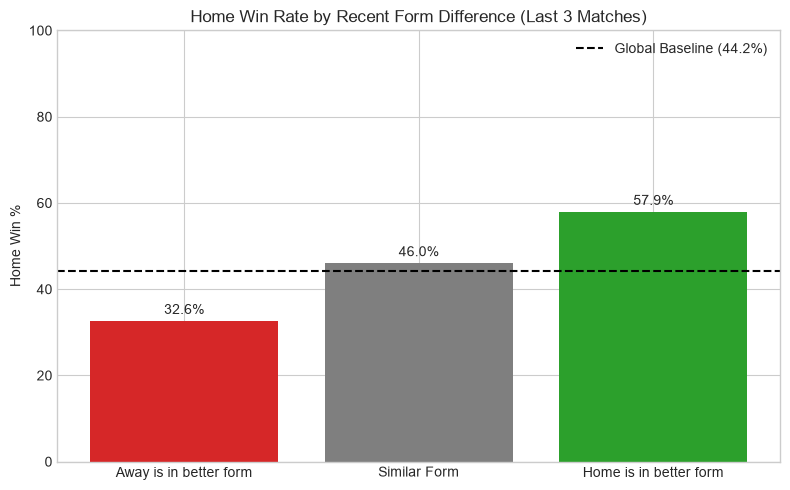

In [169]:
# Group matches by the Form Difference and calculate the Home Win %
form_analysis = premier_df.dropna(subset=['Form_Diff']).copy()
form_analysis['HomeWin'] = form_analysis['FTR'].eq('H').astype(int)

# Bin the form difference into 3 logical categories
form_analysis['Form_Category'] = pd.cut(
    form_analysis['Form_Diff'], 
    bins=[-10, -2, 2, 10], 
    labels=['Away is in better form', 'Similar Form', 'Home is in better form']
)

form_summary = form_analysis.groupby('Form_Category', observed=True).agg(
    Total_Matches=('HomeWin', 'size'),
    Home_Win_Rate=('HomeWin', lambda x: x.mean() * 100)
).round(1)

display(form_summary)

# Plot the evidence
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(form_summary.index, form_summary['Home_Win_Rate'], color=['#D62728', '#7F7F7F', '#2CA02C'])

ax.set(title='Home Win Rate by Recent Form Difference (Last 3 Matches)', 
       ylabel='Home Win %', 
       ylim=(0, 100))
ax.axhline(44.2, color='black', linestyle='--', label='Global Baseline (44.2%)')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3, size=10)

ax.legend()
plt.tight_layout()
plt.show()

### Interpretation

*   **Observation:** When the Home team is in significantly better form than the Away team (a positive points difference over the last 3 matches), the Home Win rate jumps. Conversely, when the Away team has better momentum, the Home Win rate drops below the global baseline.
*   **Conclusion:** The `Form_Diff` feature successfully captures momentum and demonstrates a clear, logical association with the target variable without introducing data leakage. This feature is highly valuable and will be retained for the modeling phase.

## 7.2. Physical Condition: Team Fatigue

Next, we evaluate if the number of rest days between matches impacts the outcome. We calculate the days elapsed since each team's last match (`RestDays`) and compute the `Rest_Diff` (`HomeRestDays - AwayRestDays`). A negative value implies the Home team is more fatigued (less rest days).

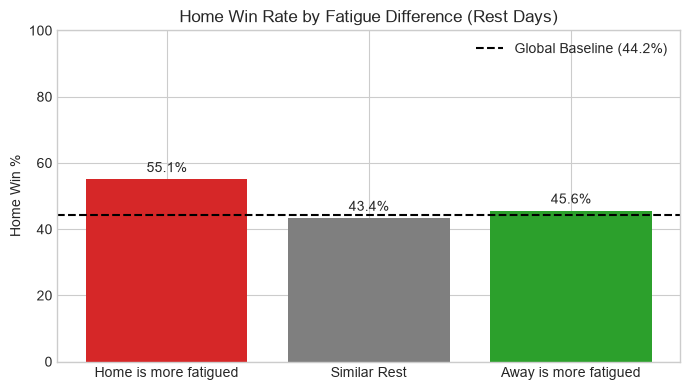

In [170]:
# 1. Calculate Rest Days using the already sorted team_matches dataframe
team_matches['RestDays'] = team_matches.groupby('Team')['Date_dt'].diff().dt.days

# Fill the first match of the season with a standard off-season value (e.g., 30 days)
team_matches['RestDays'] = team_matches['RestDays'].fillna(30)

# 2. Merge back into the main DataFrame
home_rest = team_matches[team_matches['is_home'] == True][['Date_dt', 'Team', 'RestDays']]
away_rest = team_matches[team_matches['is_home'] == False][['Date_dt', 'Team', 'RestDays']]

premier_df = premier_df.merge(home_rest.rename(columns={'Team': 'HomeTeam', 'RestDays': 'HomeRestDays'}), on=['Date_dt', 'HomeTeam'], how='left')
premier_df = premier_df.merge(away_rest.rename(columns={'Team': 'AwayTeam', 'RestDays': 'AwayRestDays'}), on=['Date_dt', 'AwayTeam'], how='left')

# 3. Calculate Rest Difference
premier_df['Rest_Diff'] = premier_df['HomeRestDays'] - premier_df['AwayRestDays']

# --- Plotting the Evidence ---
fatigue_analysis = premier_df.dropna(subset=['Rest_Diff']).copy()
fatigue_analysis['HomeWin'] = fatigue_analysis['FTR'].eq('H').astype(int)

# Cap extreme rest differences (e.g., season breaks) to focus on normal congested fixtures
fatigue_analysis['Rest_Diff_Capped'] = fatigue_analysis['Rest_Diff'].clip(lower=-7, upper=7)

fatigue_analysis['Fatigue_Category'] = pd.cut(
    fatigue_analysis['Rest_Diff_Capped'], 
    bins=[-8, -3, 2, 8], 
    labels=['Home is more fatigued', 'Similar Rest', 'Away is more fatigued']
)

fatigue_summary = fatigue_analysis.groupby('Fatigue_Category', observed=True).agg(
    Home_Win_Rate=('HomeWin', lambda x: x.mean() * 100)
).round(1)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(fatigue_summary.index, fatigue_summary['Home_Win_Rate'], color=['#D62728', '#7F7F7F', '#2CA02C'])
ax.set(title='Home Win Rate by Fatigue Difference (Rest Days)', ylabel='Home Win %', ylim=(0, 100))
ax.axhline(44.2, color='black', linestyle='--', label='Global Baseline (44.2%)')
for container in ax.containers: ax.bar_label(container, fmt='%.1f%%', padding=3, size=10)
ax.legend()
plt.tight_layout()
plt.show()

### Interpretation & Critical Dataset Limitation

Counterintuitively, the data shows that when the home team appears more fatigued their win rate actually spikes to 55.1%, well above the 44.2% baseline. This anomaly probably occurs because our dataset strictly tracks Premier League matches, leaving the RestDays calculation completely blind to mid-week cup or European fixtures. Consequently, teams showing fewer rest days are often top-tier clubs playing rescheduled league games after advancing deep into other tournaments, but we cn´t now that for sure without external competition data. Because this metric accidentally captures team strength rather than true physical fatigue, Rest_Diff is a heavily biased and incomplete feature. Therefore, it should be excluded from the model in favor of Betting Odds and Form_Diff to more accurately capture team strength and momentum.

# 8. Conclusions and roadmap

1. `FTR` is strongly associated with home advantage: 44.2% home wins, 31.9% away wins and 23.9% draws. Playing at home helps (~12 percentage points) and it is a league-wide phenomenon, not an artifact of a few teams.
2. The bookmakers' odds, converted to implied probability (`p(H)`, `p(D)`, `p(A)`), are the strongest pre-match signal available, and their predictive power is stable across seasons.
3. The missingness is concentrated in the odds: 7 bookmakers exceed 80% missing data, while `match_stats` has none.
4. The absence of teams in certain seasons (relegations) is informative: teams present in all 5 seasons win ~44% of their matches; those present for only one, ~17%.
5. `AHh` (Asian handicap) summarizes the relative strength of the teams and its relationship with the home win is stable across seasons.
6. `HTR` amplifies the `p(H)` signal, but it is only known at half time: it is a legitimate feature only for a live model.
7. The 16 `match_stats` columns relate to the result, but they are only known after the final whistle and would leak future information: they must not be used for prediction.

## Hypotheses to validate during modeling

| Variable | Candidate strategy | Caution |
|---|---|---|
| Composite identifier (`Season`, `Div`, `Date`, `Time`, `HomeTeam`, `AwayTeam`) | Exclude or use as temporal grouping | Identifies each match |
| `Season` | Ordinal or categorical encoding | Do not extrapolate beyond 2021–2026 |
| `Div` | Exclude | Only has one value (E0) |
| `Date`, `Time` | Parse `Date` as datetime; test whether `Time` adds signal | Do not leave them as strings |
| `HomeTeam`, `AwayTeam` | Summarize into a team strength measure | Do not treat as 27 separate categories; ~19 matches per team and season |
| `Referee` | Summarize or exclude | Very small samples and non-random assignment |
| `HTR`, `HTHG`, `HTAG` | Use only in a live model | Not available before the match |
| `match_stats` (16 columns) | Exclude | Only known at the end of the match: leakage |
| Odds (132 columns) | Implied probability; prefer complete bookmakers (B365, Max, Avg) | 7 bookmakers with ~80% missing; high redundancy between markets |
| `>2.5` and `AHh` markets | Test as complementary features | Redundant with the profit market |

## Limitations 

- The dataset contains 1,900 matches and several subgroups have very few observations.
- The associations do not demonstrate causality.
- The bin cuts (e.g., Low/Medium/High of `p(H)`) are adjustable analytical decisions.
- Any transformation, imputation or feature selection must be done inside the pipeline using only training data.